In [ ]:
import time
notebook_start = time.perf_counter()

# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import json,os,feos,si_units as si,numpy as np,importlib.metadata, matplotlib.pyplot as plt
from pathlib import Path
from thermoift import KIJ
from thermoift.FeosPlugin import (
    RegistryManager,
    CompositionHandler,
    ParameterBuilder,
    PropertyCalculator,
    VLECalculator,
    InterfacialTensionCalculator,
    DataProcessor,
    PlottingEngine,
    PARAMETERS)

import thermoift.semi_emperical_correlations as SEC
import thermoift.PLOT_SETTINGS as ps
from thermoift.semi_emperical_correlations import semi_emperical_correlations
from thermoift.semi_emperical_correlations import ColormapDifference
from IPython.display import display

print(f"FEOS version used: {importlib.metadata.version('feos')}")
KIJ_DIR = Path(KIJ.__file__).parent

FEOS version used: 0.9.4


## Cell 2: PARAMETER tag cell

In [ ]:
FEED_INDEX          = 1
verbose             = False
OUTPUT_FOLDER       = "OUTPUT"

# --- Resolution for cDFT and SEC colormaps (Grid size: N_T x N_P = N points max) ---#
N_T                 = 50            # Number of temperature points in PT sweep
N_P                 = 3             # Number of pressure points in PT sweep
T_initial_guess     = 200           # Initial guess for T in flash calculations [K]
P_TOL               = 1e-4          # Pressure tolerance for flash [bar]
lgrid               = 100           # cDFT domain length [Angstrom]
ngrid               = 2048          # cDFT grid points

#-------- Critical Region Enhancements ------#
dynamic_lgrid       = True          # Scale lgrid near Tc: l_grid * (1 - T/Tc)^{-0.5}
dynamic_ngrid       = True          # Scale ngrid by same factor as lgrid (keeps Å/point constant)
dynamic_scale_max   = 10.0          # Maximum scale factor cap for dynamic_lgrid/dynamic_ngrid
near_crit_power     = 1.5           # T-grid clustering near Tc: 1.0 = uniform, >1 = denser near Tc
N_T_low             = 40            # Points in uniform zone [T_min → T_split]
T_split             = 295.0         # [K] split between uniform and power-law zones


## Cell 3: Component & Feed Setup

In [3]:

CSV_PATH         = "CSV_feeds/Combined_compositions.csv"
COMPONENTS       = RegistryManager.map_csv_to_components()
raw_compositions = CompositionHandler.load_compositions(CSV_PATH, n=100).tolist()

all_compositions = []

for comp in raw_compositions:
    comp = np.array(comp, dtype=float)
    comp = comp / comp.sum()
    all_compositions.append(comp)

if FEED_INDEX is not None:
    compositions    = [all_compositions[FEED_INDEX]]
    FEED_Z          = compositions[0]
    print(f"Running single composition at index {FEED_INDEX}")
else:
    compositions    = all_compositions
    FEED_Z          = compositions[0]
    print("Running all compositions")

print(f"Loaded {len(compositions)} composition(s)")
print(f"COMPONENTS: {COMPONENTS}")
print("\nComposition(s):")
for i, comp in enumerate(compositions):
    print(f"  {i+1}: {comp}")
    
print(f"FEED_Z: {FEED_Z}")

Running single composition at index 1
Loaded 1 composition(s)
COMPONENTS: ['carbon dioxide', 'hydrogen', 'argon', 'nitrogen', 'methane', 'oxygen', 'carbon monoxide', 'hydrogen sulfide']

Composition(s):
  1: [0.95       0.002354   0.00450729 0.03680626 0.         0.
 0.00633245 0.        ]
FEED_Z: [0.95       0.002354   0.00450729 0.03680626 0.         0.
 0.00633245 0.        ]


## Cell 4: Setup - KIJ Models, and Feeds

Loaded KIJ models from CSV_feeds/KIJ_pairs.json
Active components (non-zero in at least one feed): ['carbon dioxide', 'hydrogen', 'argon', 'nitrogen', 'carbon monoxide']

K(300.0 K) =
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Symbolic K(T) matrix:


Matrix([
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0]])


Pair equations:


Eq(k_{CO2,H2}(T), 0)

Eq(k_{CO2,Ar}(T), 0)

...

Eq(k_{H2,N2}(T), 0)

Eq(k_{H2,CO}(T), 0)

Eq(k_{Ar,N2}(T), 0)

Eq(k_{Ar,CO}(T), 0)

Eq(k_{N2,CO}(T), 0)

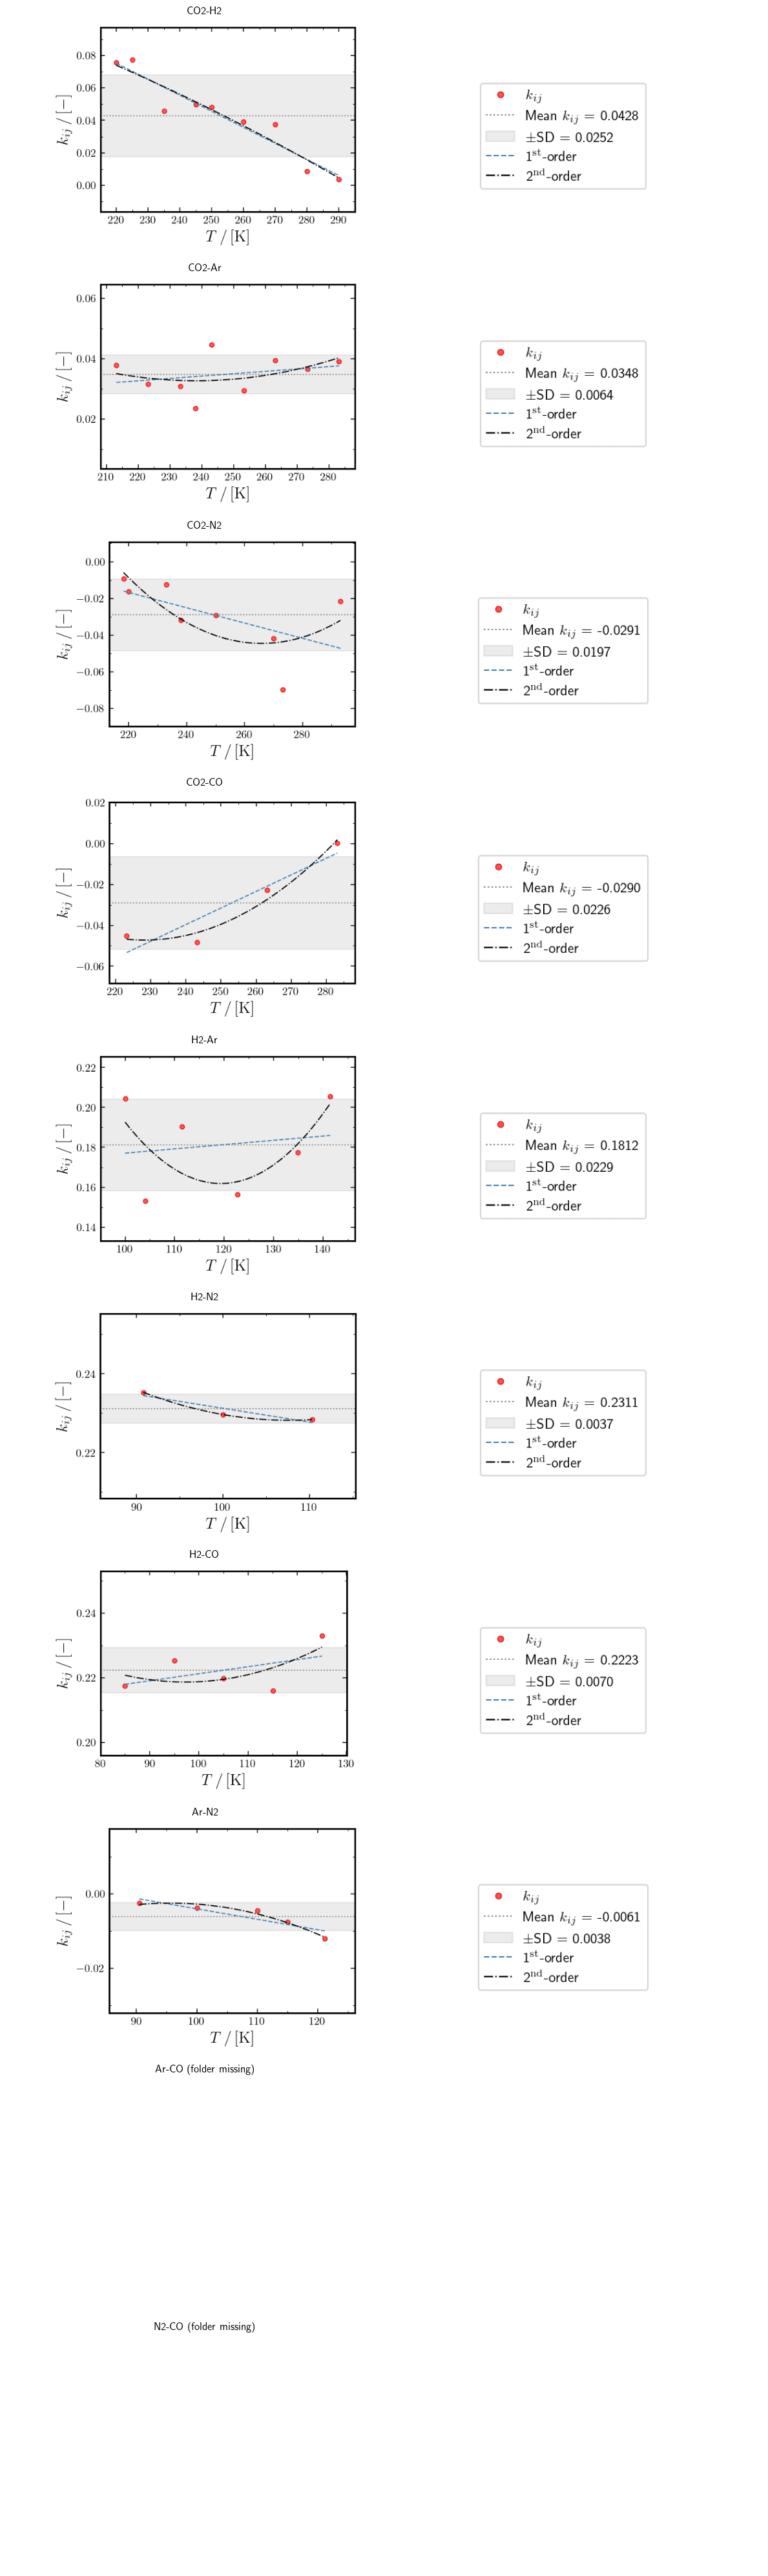

|component|molarweight|m|sigma|epsilon_k|
|-|-|-|-|-|
|carbon dioxide|43.99|2.53096|2.57855|153.31864|
|hydrogen|2.016|1.0|3.002|51.343|
|argon|39.962|1.0|3.37751|117.80903|
|nitrogen|28.006|1.23831|3.30009|89.41358|
|carbon monoxide|27.995|1.32286|3.24532|91.17087|

|component 1|component 2|k_ij|
|-|-|-|
|carbon dioxide|hydrogen|0.0|
|carbon dioxide|argon|0.0|
|carbon dioxide|nitrogen|0.0|
|carbon dioxide|carbon monoxide|0.0|
|hydrogen|argon|0.0|
|hydrogen|nitrogen|0.0|
|hydrogen|carbon monoxide|0.0|
|argon|nitrogen|0.0|
|argon|carbon monoxide|0.0|
|nitrogen|carbon monoxide|0.0|

In [4]:
KIJ_PAIRS_FILE = Path("CSV_feeds/KIJ_pairs.json")
KIJ_LABELS     = RegistryManager.kij_labels_from_names(COMPONENTS)

with open(KIJ_PAIRS_FILE) as f:
    kij_overrides = json.load(f)

KIJ_map = ParameterBuilder.build_kij_map(KIJ_LABELS, kij_overrides)
print(f"Loaded KIJ models from {KIJ_PAIRS_FILE}")

feeds = CompositionHandler.make_feeds(*compositions)
ACTIVE_COMPONENTS, ACTIVE_KIJ_LABELS, active_map = CompositionHandler.active_components_from_feeds(
    feeds, COMPONENTS, KIJ_map)
print(f"Active components (non-zero in at least one feed): {ACTIVE_COMPONENTS}")

builder    = KIJ.KIJMatrixBuilder(root=str(KIJ_DIR), kij_filename="KIJ.json", verbose=False)
parameters = ParameterBuilder.build_parameters(ACTIVE_COMPONENTS, T_K=300.0, kij_builder=builder, model_map=active_map)
components = RegistryManager.get_component_names(parameters)
builder.build_and_display(components=ACTIVE_KIJ_LABELS, model_map=active_map, T_eval=300.0,
                          show_matrix=True, show_pair_equations=True)
builder.show_pair_plots(ACTIVE_KIJ_LABELS, mode="all")

parameters

## Cell 5: Phase envelope computation with T-dependent kij 

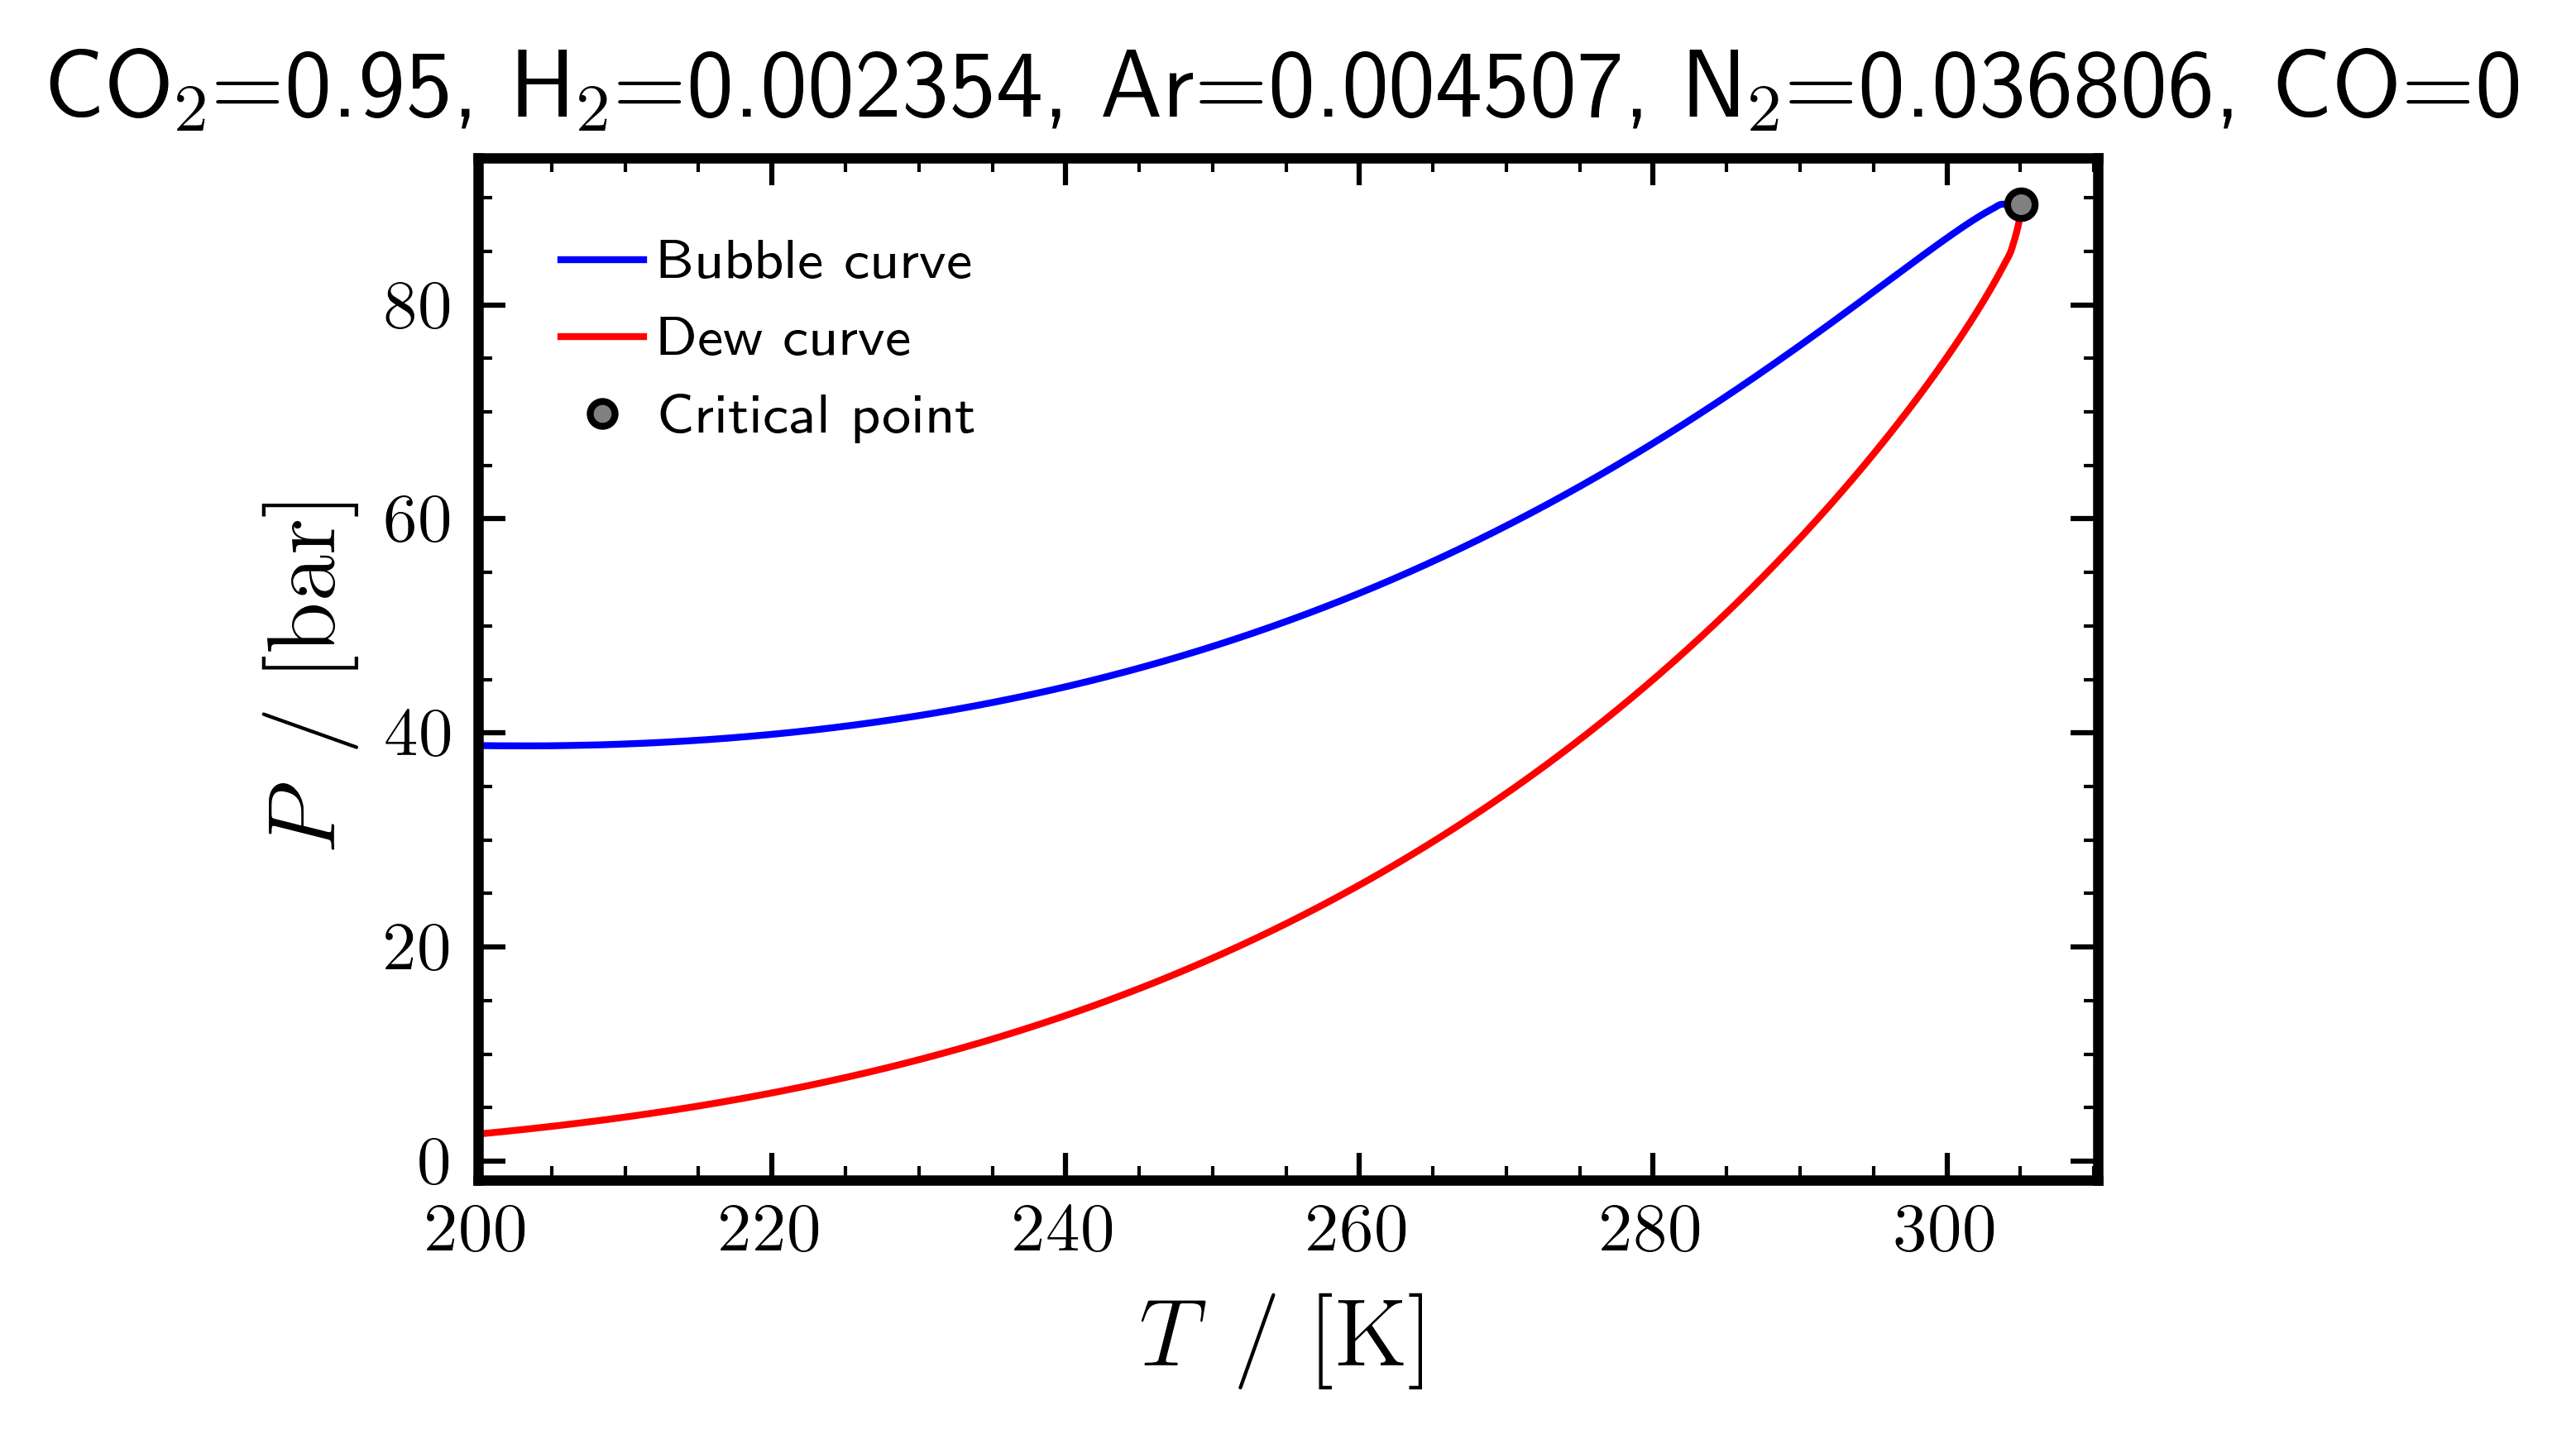

In [5]:
PT_results = {}
VLE_DFT    = {}

for k, z in enumerate(feeds, start=1):
    z    = CompositionHandler.normalize_z(z)
    feed = CompositionHandler.compute_feed_moles(z)

    if verbose:
        print(f"\nFeed {k}: z = {z}")

    active_z, active_components, is_reduced = CompositionHandler.reduce_components(z, COMPONENTS, verbose=verbose)
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    active_map  = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)

    parameters_ref = PARAMETERS(active_components, T_K=T_initial_guess, kij_builder=builder, model_map=active_map)
    eos = feos.HelmholtzEnergyFunctional.pcsaft(parameters_ref)

    try:
        CT, CP = VLECalculator.compute_critical_point(eos, active_z, T_guess=T_initial_guess)

        if verbose:
            print(f"Critical Point: T = {CT/si.KELVIN:.2f} K, P = {CP/si.BAR:.2f} bar")

        Tc_K     = float(CT / si.KELVIN)
        Pc_bar   = float(CP / si.BAR)
        eos_fn   = VLECalculator.make_eos_factory(active_components, builder, active_map)
        T_values = VLECalculator.make_T_grid(T_initial_guess, Tc_K, N_T)

        T_bubble_all, P_bubble_all, T_dew_all, P_dew_all = VLECalculator.compute_phase_envelope(
            eos_fn, T_values, active_feed, verbose, Tc=Tc_K, Pc=Pc_bar)

        PT_results[f"feed_{k}"] = {
            "z":      [round(float(x), 6) for x in np.asarray(z, dtype=float)],
            "TC_K":   round(float(CT / si.KELVIN), 2),
            "PC_bar": round(float(CP / si.BAR), 2),
            "bubble": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bubble_all, P_bubble_all)],
            "dew":    [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew_all, P_dew_all)],
        }

    except Exception as e:
        print(f"Feed {k}: z = {z}")
        print("CT computation failed:", e)

# Quick estimation: plot, save PT diagrams, initialize VLE_DFT envelope, and export envelope CSV
PT_figs = {}
for feed_key, feed in PT_results.items():
    fig, ax = PlottingEngine.plot_phase_diagram(PT_results, feed_key, parameters)
    PlottingEngine.save_plots(fig, f"PT_{feed_key}", folder=OUTPUT_FOLDER)
    PT_figs[feed_key] = (fig, ax)

    bub_pts   = sorted(feed.get("bubble", []), key=lambda p: p["T_K"])
    dew_pts   = sorted(feed.get("dew",    []), key=lambda p: p["T_K"])
    T_bub_arr = np.array([p["T_K"]   for p in bub_pts])
    P_bub_arr = np.array([p["P_bar"] for p in bub_pts])
    T_dew_arr = np.array([p["T_K"]   for p in dew_pts])
    P_dew_arr = np.array([p["P_bar"] for p in dew_pts])

    VLE_DFT[feed_key] = {
        "z": list(feed["z"]),
        "phase_envelope": {
            "bubble_curve": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bub_arr, P_bub_arr)],
            "dew_curve":    [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew_arr, P_dew_arr)],
            "isothermal_lines": []
        },
        "interfacial_data": {}
    }
    DataProcessor.export_to_csv(
        {feed_key: VLE_DFT[feed_key]},
        folder=OUTPUT_FOLDER,
        verbose=verbose,
        filename_interfacial=None,
        filename_envelope=f"{feed_key}_envelope",
    )

## Cell 6: cDFT: PT space sweep, TP flash, and planar interface IFT

IFT failed at T=295.0 K, P=73.57 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=295.0 K, P=80.41 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=297.3 K, P=76.67 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=297.3 K, P=82.67 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=298.6 K, P=73.11 bar: `DFT` did not converge within the maximum number of iterations.


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=298.57233947189246 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


IFT failed at T=298.6 K, P=78.55 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=298.6 K, P=83.99 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=299.7 K, P=75.24 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=299.7 K, P=80.16 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=300.7 K, P=77.23 bar: `DFT` did not converge within the maximum number of iterations.
IFT failed at T=300.7 K, P=81.63 bar: `DFT` did not converge within the maximum number of iterations.


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.67073543566966 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=301.5803055691441 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=302.4307655459333 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


IFT failed at T=301.6 K, P=79.15 bar: `DFT` did not converge within the maximum number of iterations.


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=303.235021774383 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=304.0017313960153 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=304.73705742844436 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


TP flash failed at T=304.7 K, P=88.27 bar: `rachford_rice` encountered illegal values during the iteration.
TP flash failed at T=304.7 K, P=88.39 bar: `rachford_rice` encountered illegal values during the iteration.


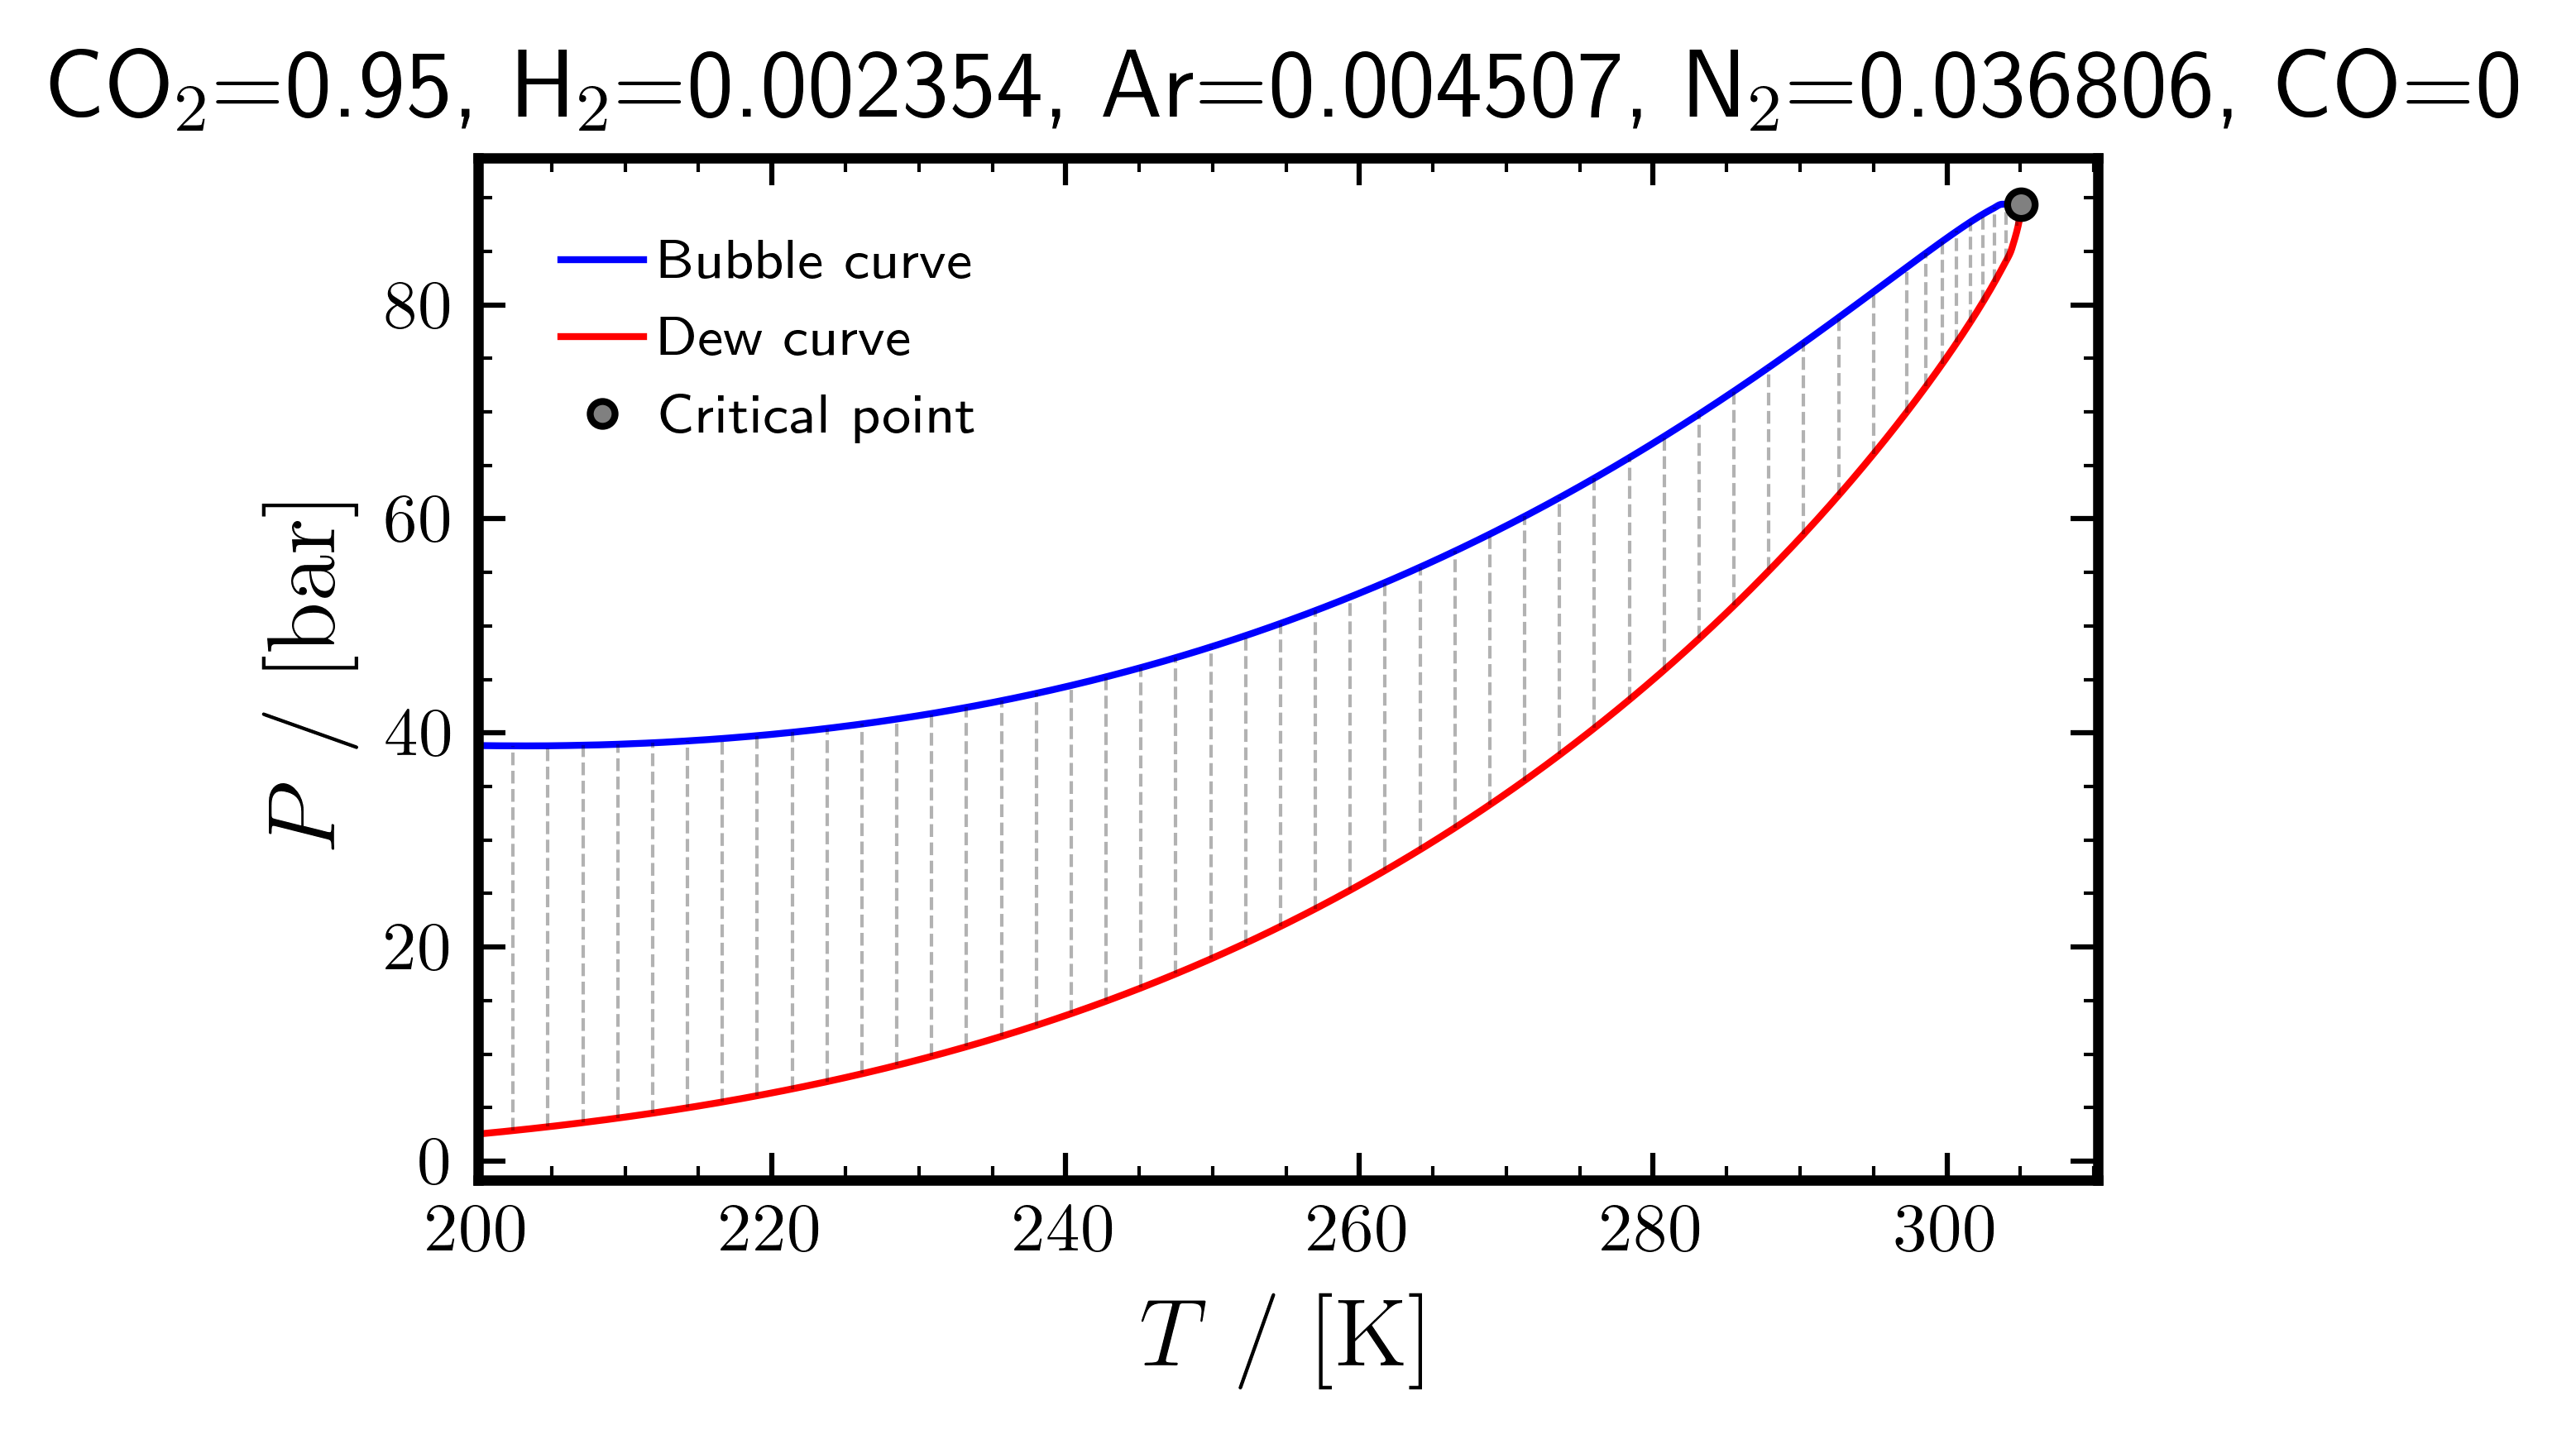

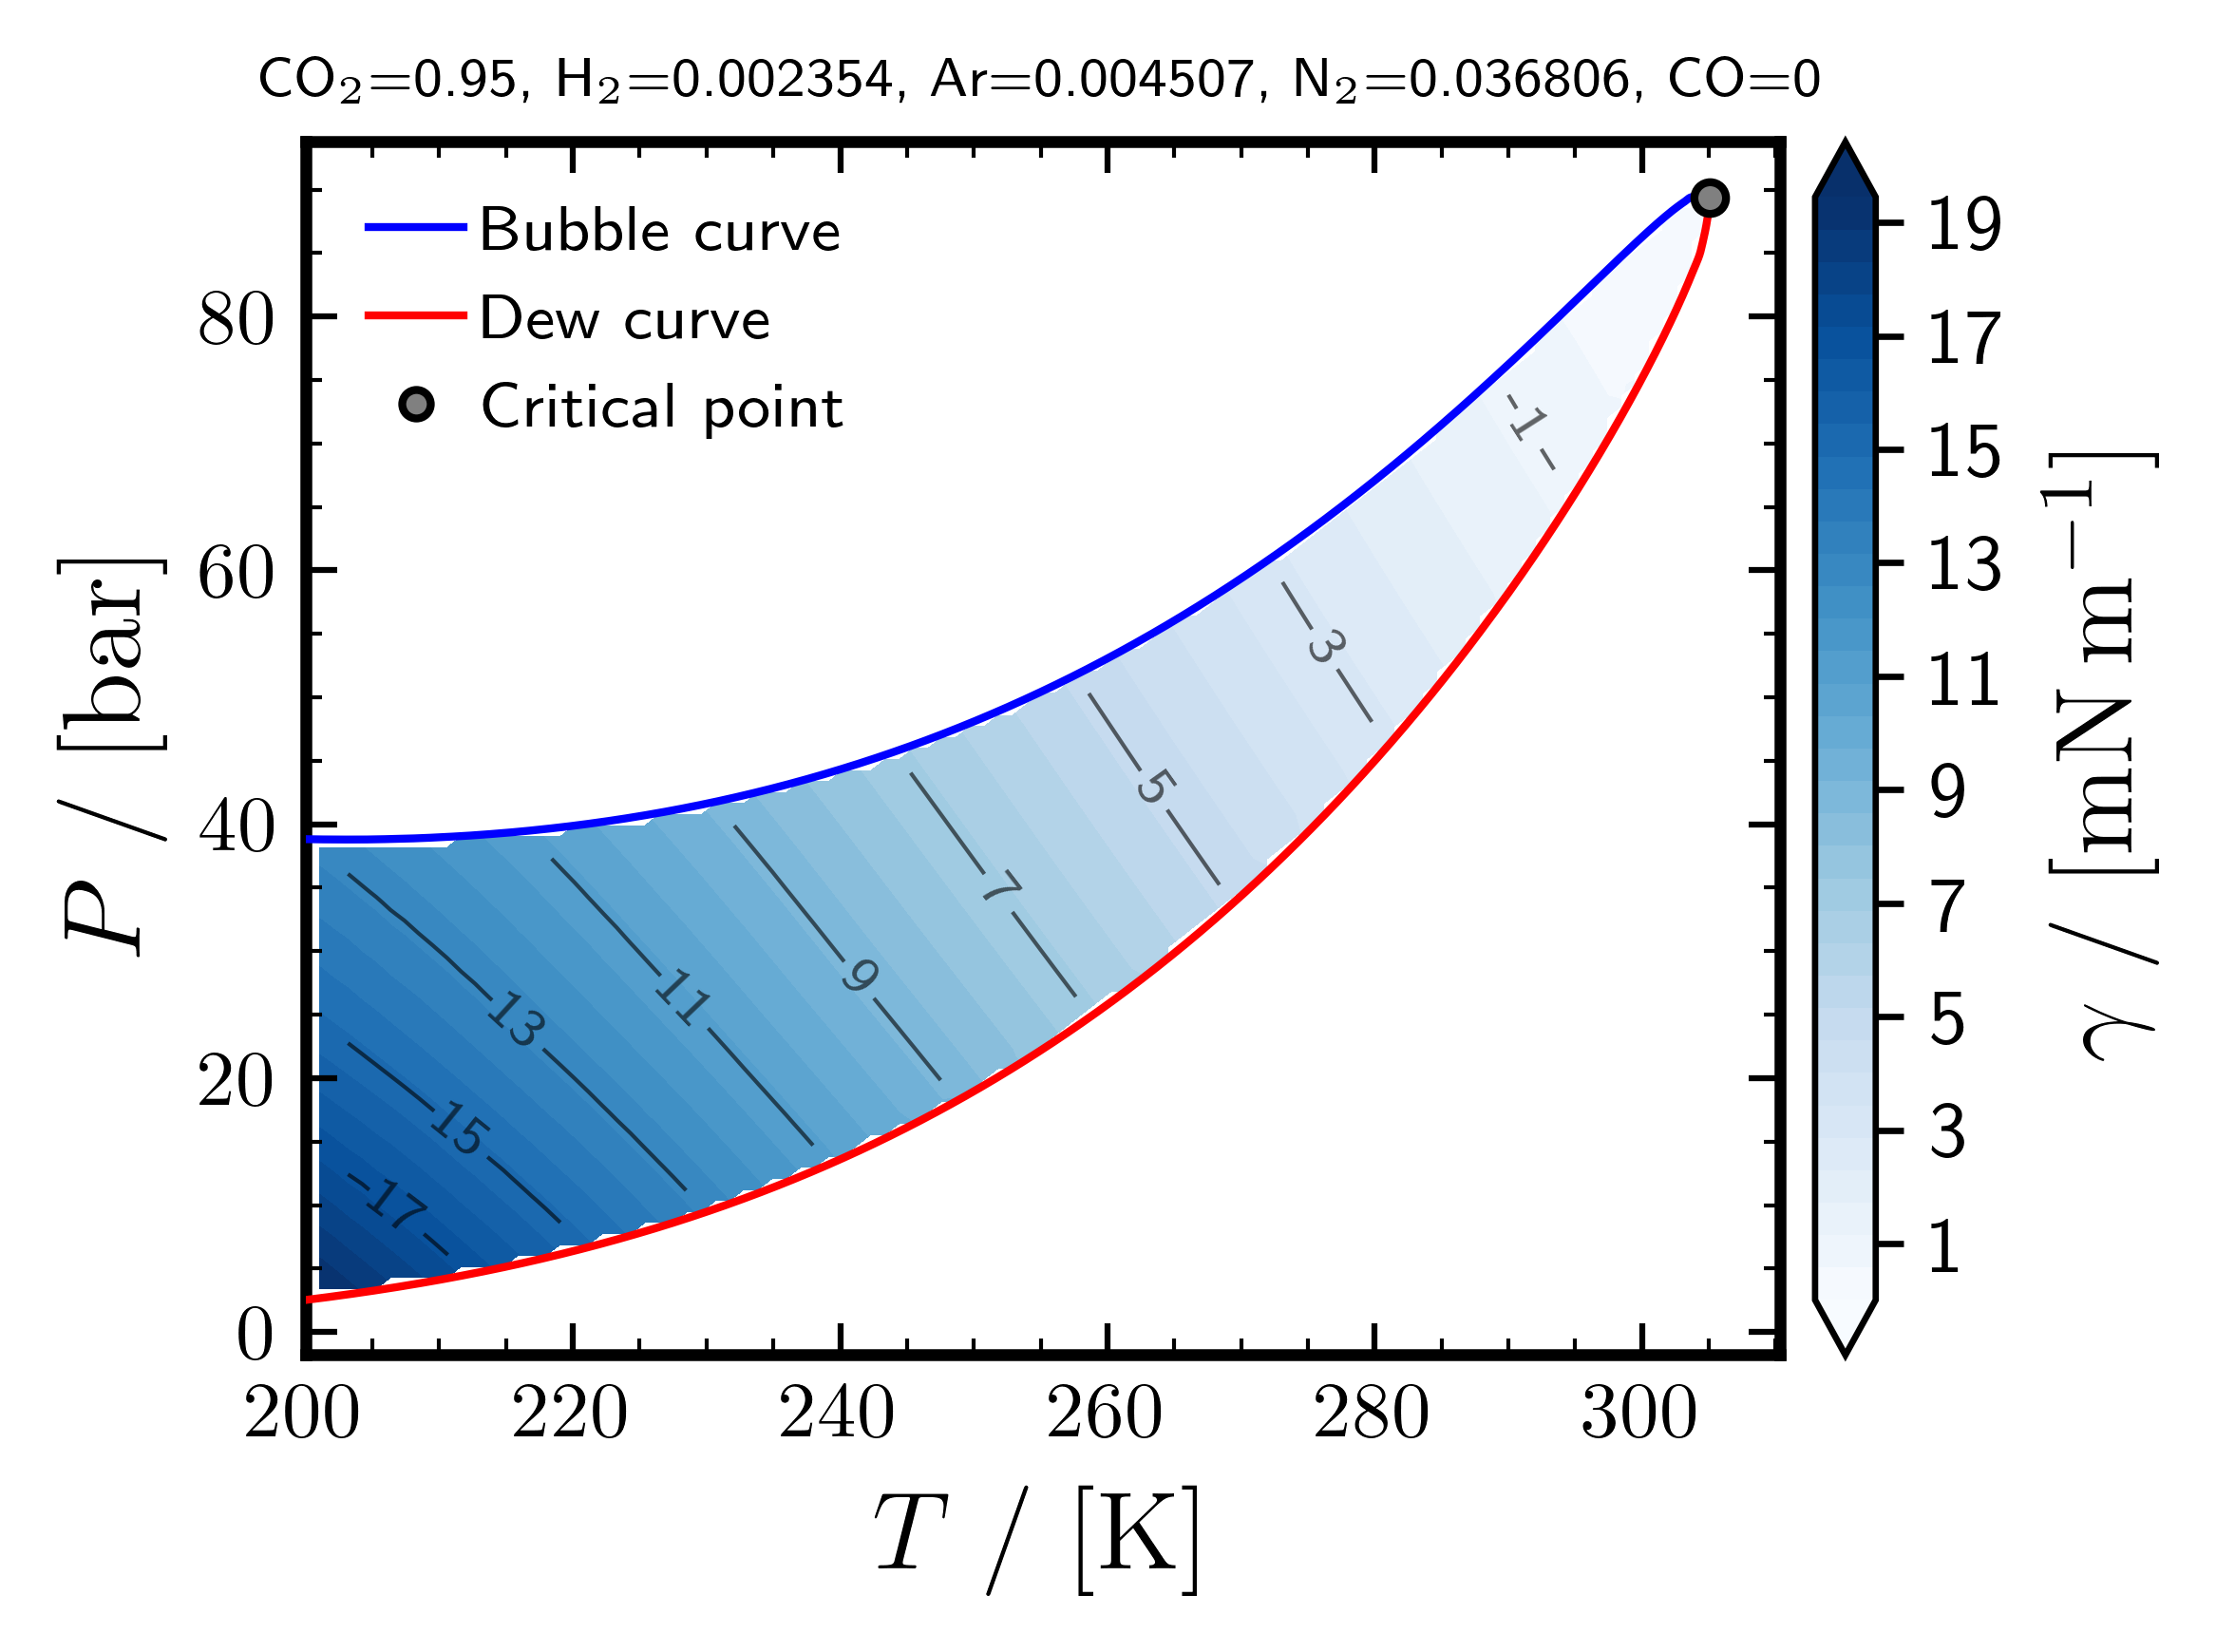

In [6]:
sec_cdft = semi_emperical_correlations(n_grid=ngrid, l_grid=lgrid, dynamic_lgrid=dynamic_lgrid,
                                       dynamic_ngrid=dynamic_ngrid, max_scale=dynamic_scale_max)

for feed_key, feed in PT_results.items():

    TP_z = np.array(feed.get("z", []))
    CT   = feed["TC_K"] * si.KELVIN
    CP   = feed["PC_bar"] * si.BAR
    Tc_K = feed["TC_K"]

    active_z, active_components, is_reduced = CompositionHandler.reduce_components(TP_z, COMPONENTS, verbose=verbose)
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    active_map  = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)

    fig, ax = PT_figs[feed_key]

    # Build interpolation arrays from phase envelope (fine resolution from T_STEP=1)
    bub_pts = sorted(feed.get("bubble", []), key=lambda p: p["T_K"])
    dew_pts = sorted(feed.get("dew", []),    key=lambda p: p["T_K"])
    T_bub_arr = np.array([p["T_K"]  for p in bub_pts])
    P_bub_arr = np.array([p["P_bar"] for p in bub_pts])
    T_dew_arr = np.array([p["T_K"]  for p in dew_pts])
    P_dew_arr = np.array([p["P_bar"] for p in dew_pts])

    # T-grid with power-law clustering near Tc (near_crit_power=1 → uniform)
    T_min = max(T_bub_arr.min(), T_dew_arr.min())
    # Two-zone T-grid: uniform in 200–290 K, power-law clustering near Tc
    T_max = min(T_bub_arr.max(), T_dew_arr.max()) * 0.999
    T_zone1 = np.linspace(T_min, T_split, N_T_low, endpoint=False)
    N_T_high = N_T - N_T_low
    T_zone2 = T_split + np.linspace(0.0, 1.0, N_T_high) ** (1.0 / near_crit_power) * (T_max - T_split)
    T_grid = np.concatenate([T_zone1, T_zone2])

    # VLE_DFT[feed_key] already initialized with phase_envelope in Cell 6
    VLE_DFT[feed_key]["interfacial_data"] = {}

    if verbose:
        print(f"\n{feed_key}: cDFT sweep with N_T={N_T}, N_P={N_P}")

    for T_K in T_grid:
        # Interpolate bubble/dew pressures at this T
        P_b = float(np.interp(T_K, T_bub_arr, P_bub_arr))
        P_d = float(np.interp(T_K, T_dew_arr, P_dew_arr))

        if P_b <= P_d:
            continue

        T = int(round(T_K))  # integer key for storage

        VLE_DFT[feed_key]["phase_envelope"]["isothermal_lines"].append(
            {"T_K": float(T_K), "P_bubble_bar": P_b, "P_dew_bar": P_d}
        )

        # Rebuild parameters with T-dependent kij
        parameters_T = PARAMETERS(active_components, T_K=float(T_K), kij_builder=builder, model_map=active_map)
        eos_T        = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)
        molar_masses = PropertyCalculator.molar_masses(parameters_T)

        # --- Pure CO2 properties at this temperature (inherits dynamic_lgrid/dynamic_ngrid from instance) ---
        gamma0_CO2, rhoL0_CO2, rhoV0_CO2, Tc_CO2, Pc_CO2, Psat_CO2 = \
            sec_cdft._pure_component_cDFT("carbon dioxide", float(T_K))

        pressures = np.linspace(P_d * 1.01, P_b * 0.99, N_P)
        ax.plot([T_K, T_K], [P_d, P_b], linewidth=0.5, linestyle="--", color="k", alpha=0.3)

        VLE_DFT[feed_key]["interfacial_data"][T_K] = []

        for P in pressures:
            if verbose:
                print(f"T = {T_K:.1f} K | P_flash = {P:.2f} | z = {active_z}")

            try:
                eq, x, y, liquid_density, vapor_density = VLECalculator.tp_flash(
                    eos_T, T_K*si.KELVIN, P*si.BAR, active_z*si.MOL, molar_masses)
            except Exception as e:
                print(f"TP flash failed at T={T_K:.1f} K, P={P:.2f} bar: {e}")
                continue

            interface = InterfacialTensionCalculator.build_planar_interface(
                eq, critical_temperature=CT, n_grid=ngrid, l_grid=lgrid,
                T_K=float(T_K), Tc_K=Tc_K, dynamic_lgrid=dynamic_lgrid,
                dynamic_ngrid=dynamic_ngrid, max_scale=dynamic_scale_max)

            try:
                gamma_mN_m, interfacial_thickness_nm, enrichment = \
                    InterfacialTensionCalculator.solve_interface_properties(interface)
            except Exception as e:
                print(f"IFT failed at T={T_K:.1f} K, P={P:.2f} bar: {e}")
                gamma_mN_m = np.nan
                interfacial_thickness_nm = np.nan
                enrichment = tuple(np.nan for _ in active_components)

            if verbose:
                print(f"T = {T_K:.1f} K | P_flash = {P:.2f} bar | gamma = {gamma_mN_m:.6f} mN/m")

            row_data = DataProcessor.assemble_row(
                T_K, P, active_z, CT, CP, P_b, P_d,
                liquid_density, vapor_density,
                x, y, gamma_mN_m, interfacial_thickness_nm,
                active_components, enrichment,
                gamma0_CO2=gamma0_CO2,
                rhoL0_CO2_mol_cm3=rhoL0_CO2,
                rhoV0_CO2_mol_cm3=rhoV0_CO2,
                Tc_CO2=Tc_CO2,
                Psat_CO2=Psat_CO2,
                ML_mode=False,
            )
            VLE_DFT[feed_key]["interfacial_data"][T_K].append(row_data)

    # Save meshed PT diagram (envelope + isothermal lines) as a separate file
    PlottingEngine.save_plots(fig, f"PT_mesh_{feed_key}", folder=OUTPUT_FOLDER)
    display(fig)

    fig_gamma = PlottingEngine.plot_interfacial_tension_map(PT_results, VLE_DFT, feed_key, parameters)
    if fig_gamma is not None:
        PlottingEngine.save_plots(fig_gamma, f"Gamma_cDFT_{feed_key}", folder=OUTPUT_FOLDER)

    saved_files = DataProcessor.export_to_csv(
        {feed_key: VLE_DFT[feed_key]},
        folder=OUTPUT_FOLDER,
        verbose=verbose,
        filename_interfacial=f"{feed_key}_interfacial",
        filename_envelope=None,
    )

summary = DataProcessor.summarize_vle_dft(VLE_DFT, verbose=verbose)
if verbose:
    print(summary)

## Cell 7: SEC Compute PT colormap data for each feed

In [7]:
sec_results = {}

for feed_key, feed in PT_results.items():

    FEED_Z = np.array(feed["z"], dtype=float)
    FEED_Z = FEED_Z / FEED_Z.sum()

    Tc_K   = feed["TC_K"]
    Pc_bar = feed["PC_bar"]

    # Reduce to active components for this feed
    active_z, active_components, is_reduced = CompositionHandler.reduce_components(
        FEED_Z, COMPONENTS, verbose=verbose)
    
    active_map = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)

    # Extract bubble/dew arrays from PT_results
    T_bub_all = [pt["T_K"]   for pt in feed["bubble"]]
    P_bub_all = [pt["P_bar"] for pt in feed["bubble"]]
    T_dew_all = [pt["T_K"]   for pt in feed["dew"]]
    P_dew_all = [pt["P_bar"] for pt in feed["dew"]]

    # Feed-specific T_grid with power-law clustering near Tc
    T_bub_arr = np.array(T_bub_all, dtype=float)
    T_dew_arr = np.array(T_dew_all, dtype=float)
    T_min = max(T_bub_arr.min(), T_dew_arr.min())
    # Two-zone T-grid: uniform in 200–290 K, power-law clustering near Tc
    T_max = min(T_bub_arr.max(), T_dew_arr.max()) * 0.999
    T_zone1 = np.linspace(T_min, T_split, N_T_low, endpoint=False)
    N_T_high = N_T - N_T_low
    T_zone2 = T_split + np.linspace(0.0, 1.0, N_T_high) ** (1.0 / near_crit_power) * (T_max - T_split)
    T_grid_local = np.concatenate([T_zone1, T_zone2])

    # Feed-specific EOS
    params_ref = PARAMETERS(
        active_components,
        T_K=T_initial_guess,
        kij_builder=builder,
        model_map=active_map,
    )
    eos_ref = feos.HelmholtzEnergyFunctional.pcsaft(params_ref)

    # New SEC object per feed to avoid cache carry-over
    model = semi_emperical_correlations(n_grid=ngrid, l_grid=lgrid, dynamic_lgrid=dynamic_lgrid,
                                        dynamic_ngrid=dynamic_ngrid, max_scale=dynamic_scale_max)

    # --- Parachor (T-dependent) ---
    data_parachor = model.compute_PT_colormap_data(
        component_names=active_components,
        feed_z=active_z,
        eos=eos_ref,
        T_bub=T_bub_all,
        P_bub=P_bub_all,
        T_dew=T_dew_all,
        P_dew=P_dew_all,
        method="parachor",
        n_exp=3.87,
        kij_parachor=0.0,
        n_T=N_T,
        n_P=N_P,
        recompute_parachor=True,
        kij_builder=builder,
        model_map=active_map,
        T_grid=T_grid_local,
    )

    # --- WSD method (with correction) ---
    data_wsd = model.compute_PT_colormap_data(
        component_names=active_components,
        feed_z=active_z,
        eos=eos_ref,
        T_bub=T_bub_all,
        P_bub=P_bub_all,
        T_dew=T_dew_all,
        P_dew=P_dew_all,
        method="wsd",
        phi_wsd=1.0,
        wsd_correction=True,
        n_T=N_T,
        n_P=N_P,
        kij_builder=builder,
        model_map=active_map,
        T_grid=T_grid_local,
    )

    # --- WSD method (without correction) ---
    data_wsd_nocorr = model.compute_PT_colormap_data(
        component_names=active_components,
        feed_z=active_z,
        eos=eos_ref,
        T_bub=T_bub_all,
        P_bub=P_bub_all,
        T_dew=T_dew_all,
        P_dew=P_dew_all,
        method="wsd",
        phi_wsd=1.0,
        wsd_correction=False,
        n_T=N_T,
        n_P=N_P,
        kij_builder=builder,
        model_map=active_map,
        T_grid=T_grid_local,
    )

    sec_results[feed_key] = {
        "z_full": FEED_Z,
        "z": active_z,
        "components": active_components,
        "params_ref": params_ref,
        "Tc_K": Tc_K,
        "Pc_bar": Pc_bar,
        "T_bub_all": T_bub_all,
        "P_bub_all": P_bub_all,
        "T_dew_all": T_dew_all,
        "P_dew_all": P_dew_all,
        "parachor": data_parachor,
        "wsd": data_wsd,
        "wsd_nocorr": data_wsd_nocorr,
    }

    print(f"Finished SEC for {feed_key} with components {active_components}")

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=298.57233947189246 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.67073543566966 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=301.5803055691441 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:290: UserWarning: cD

Finished SEC for feed_1 with components ['carbon dioxide', 'hydrogen', 'argon', 'nitrogen', 'carbon monoxide']


## Cell 8: SEC PT colormaps

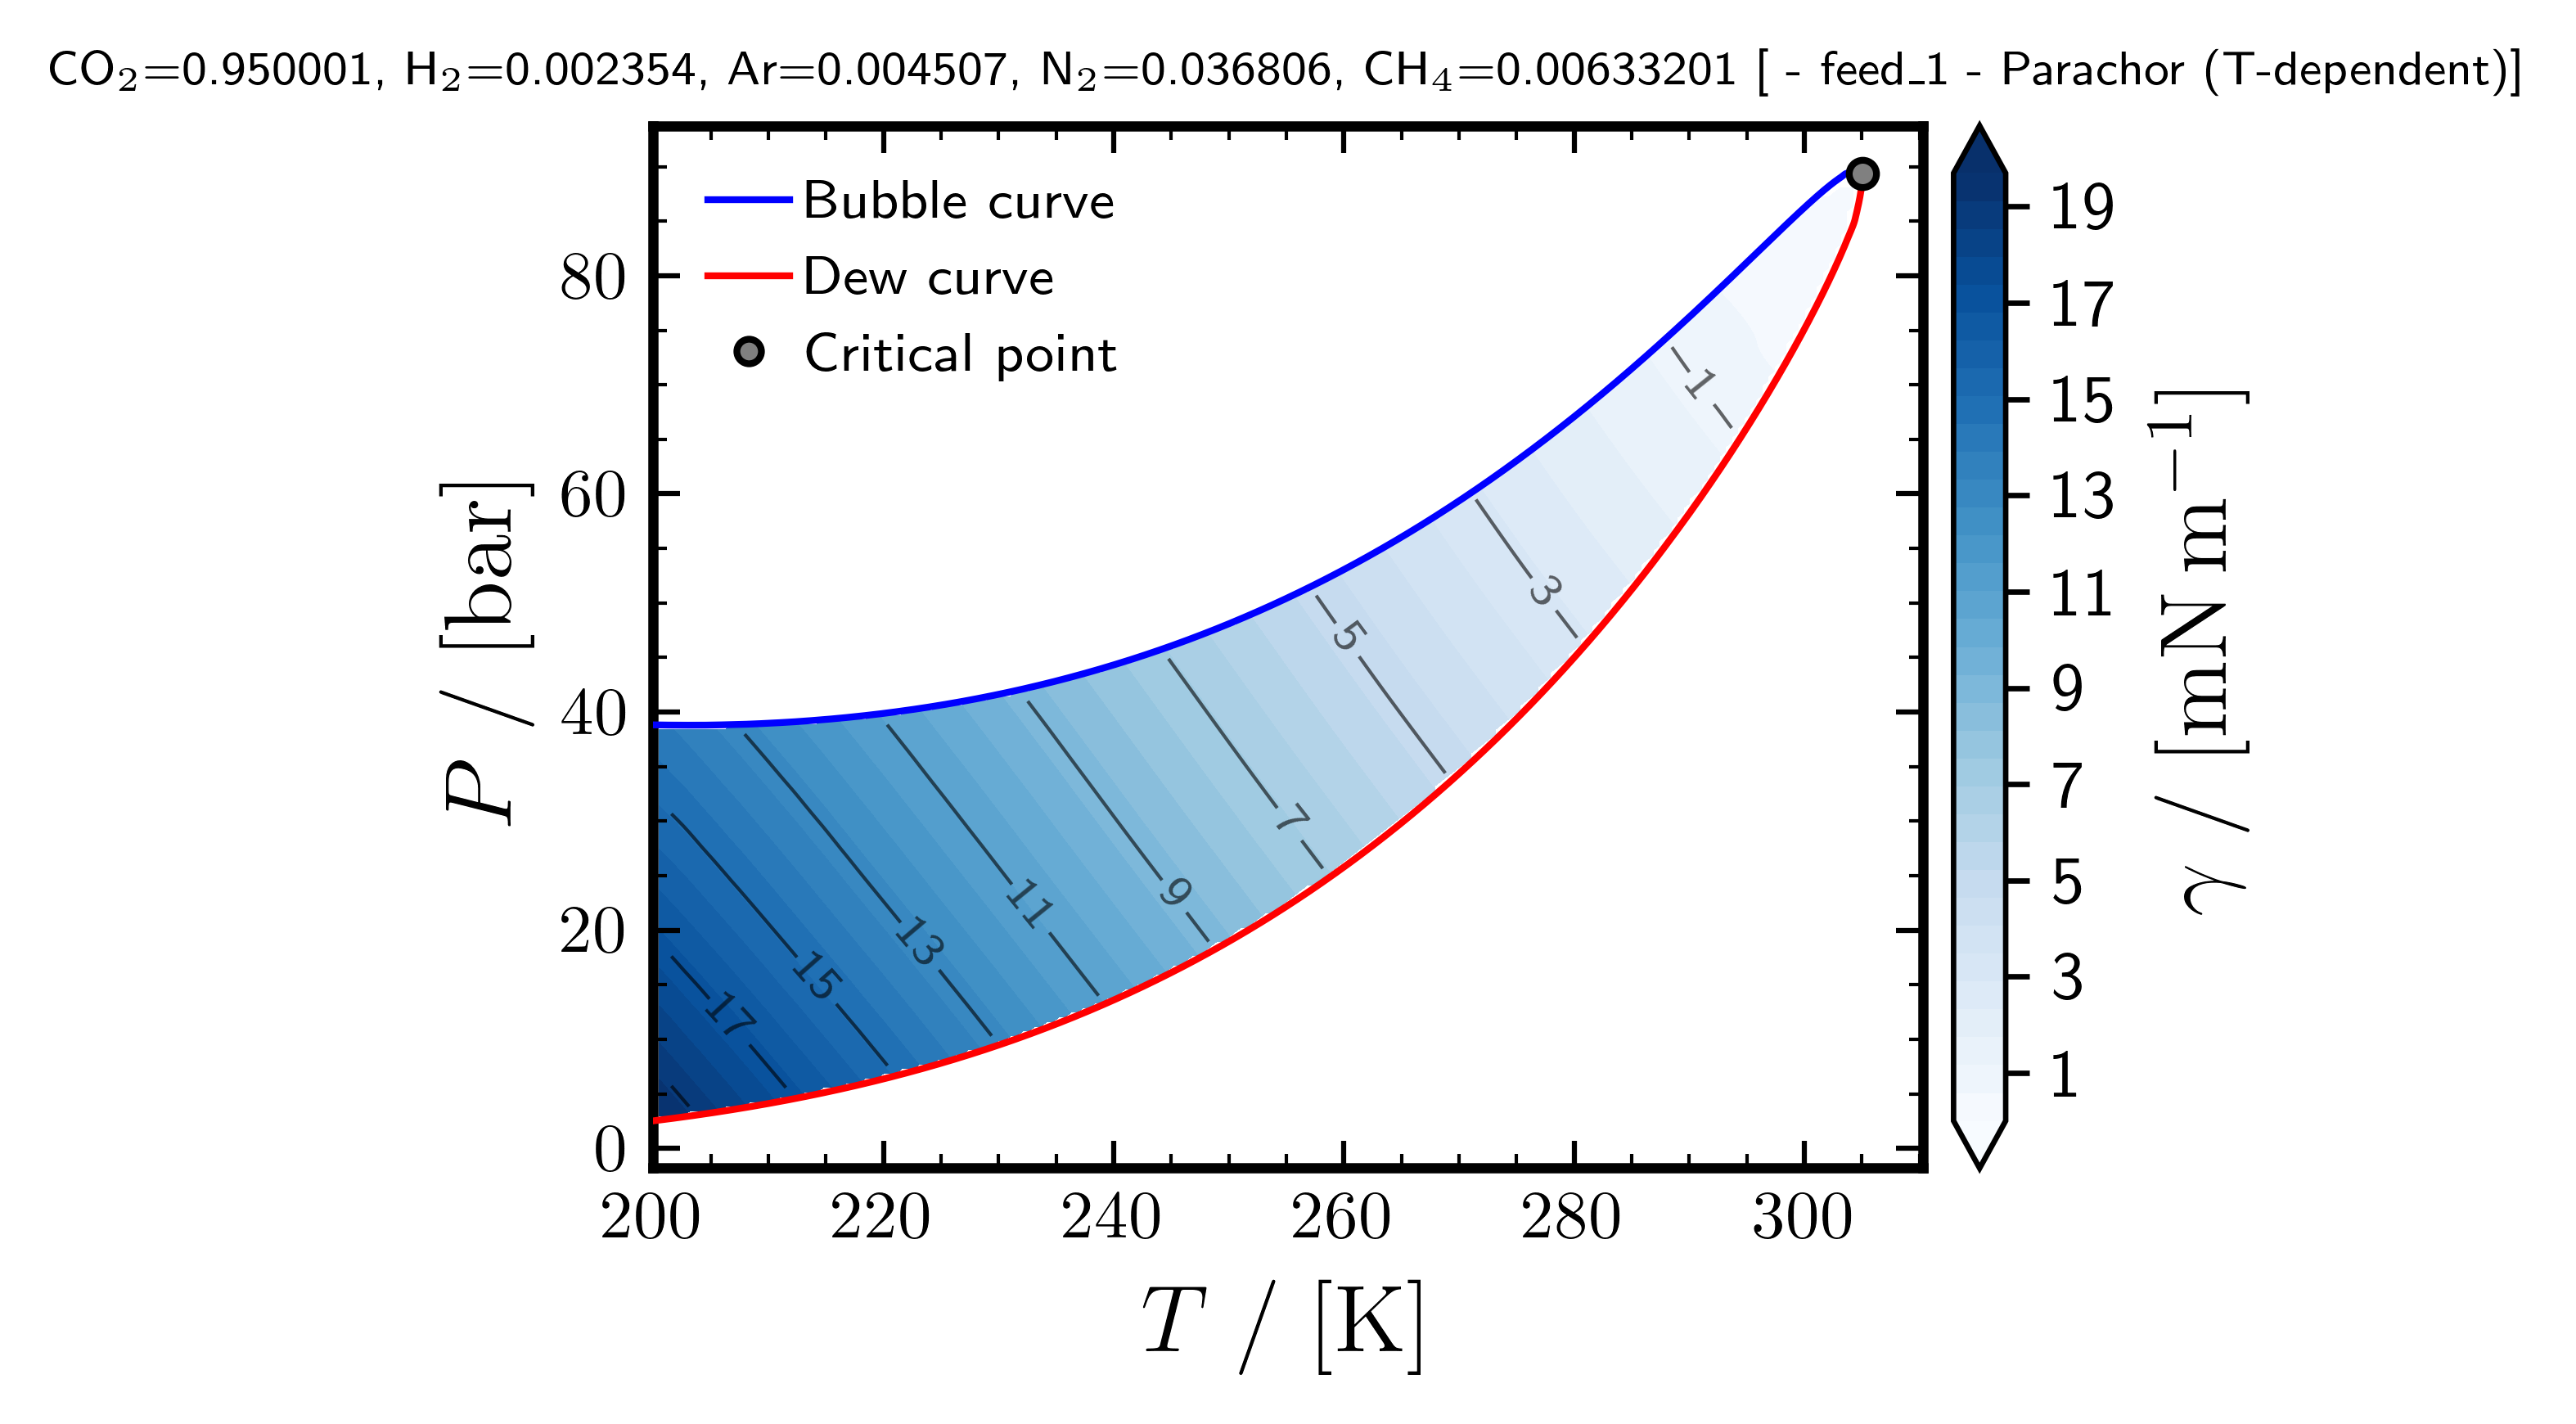

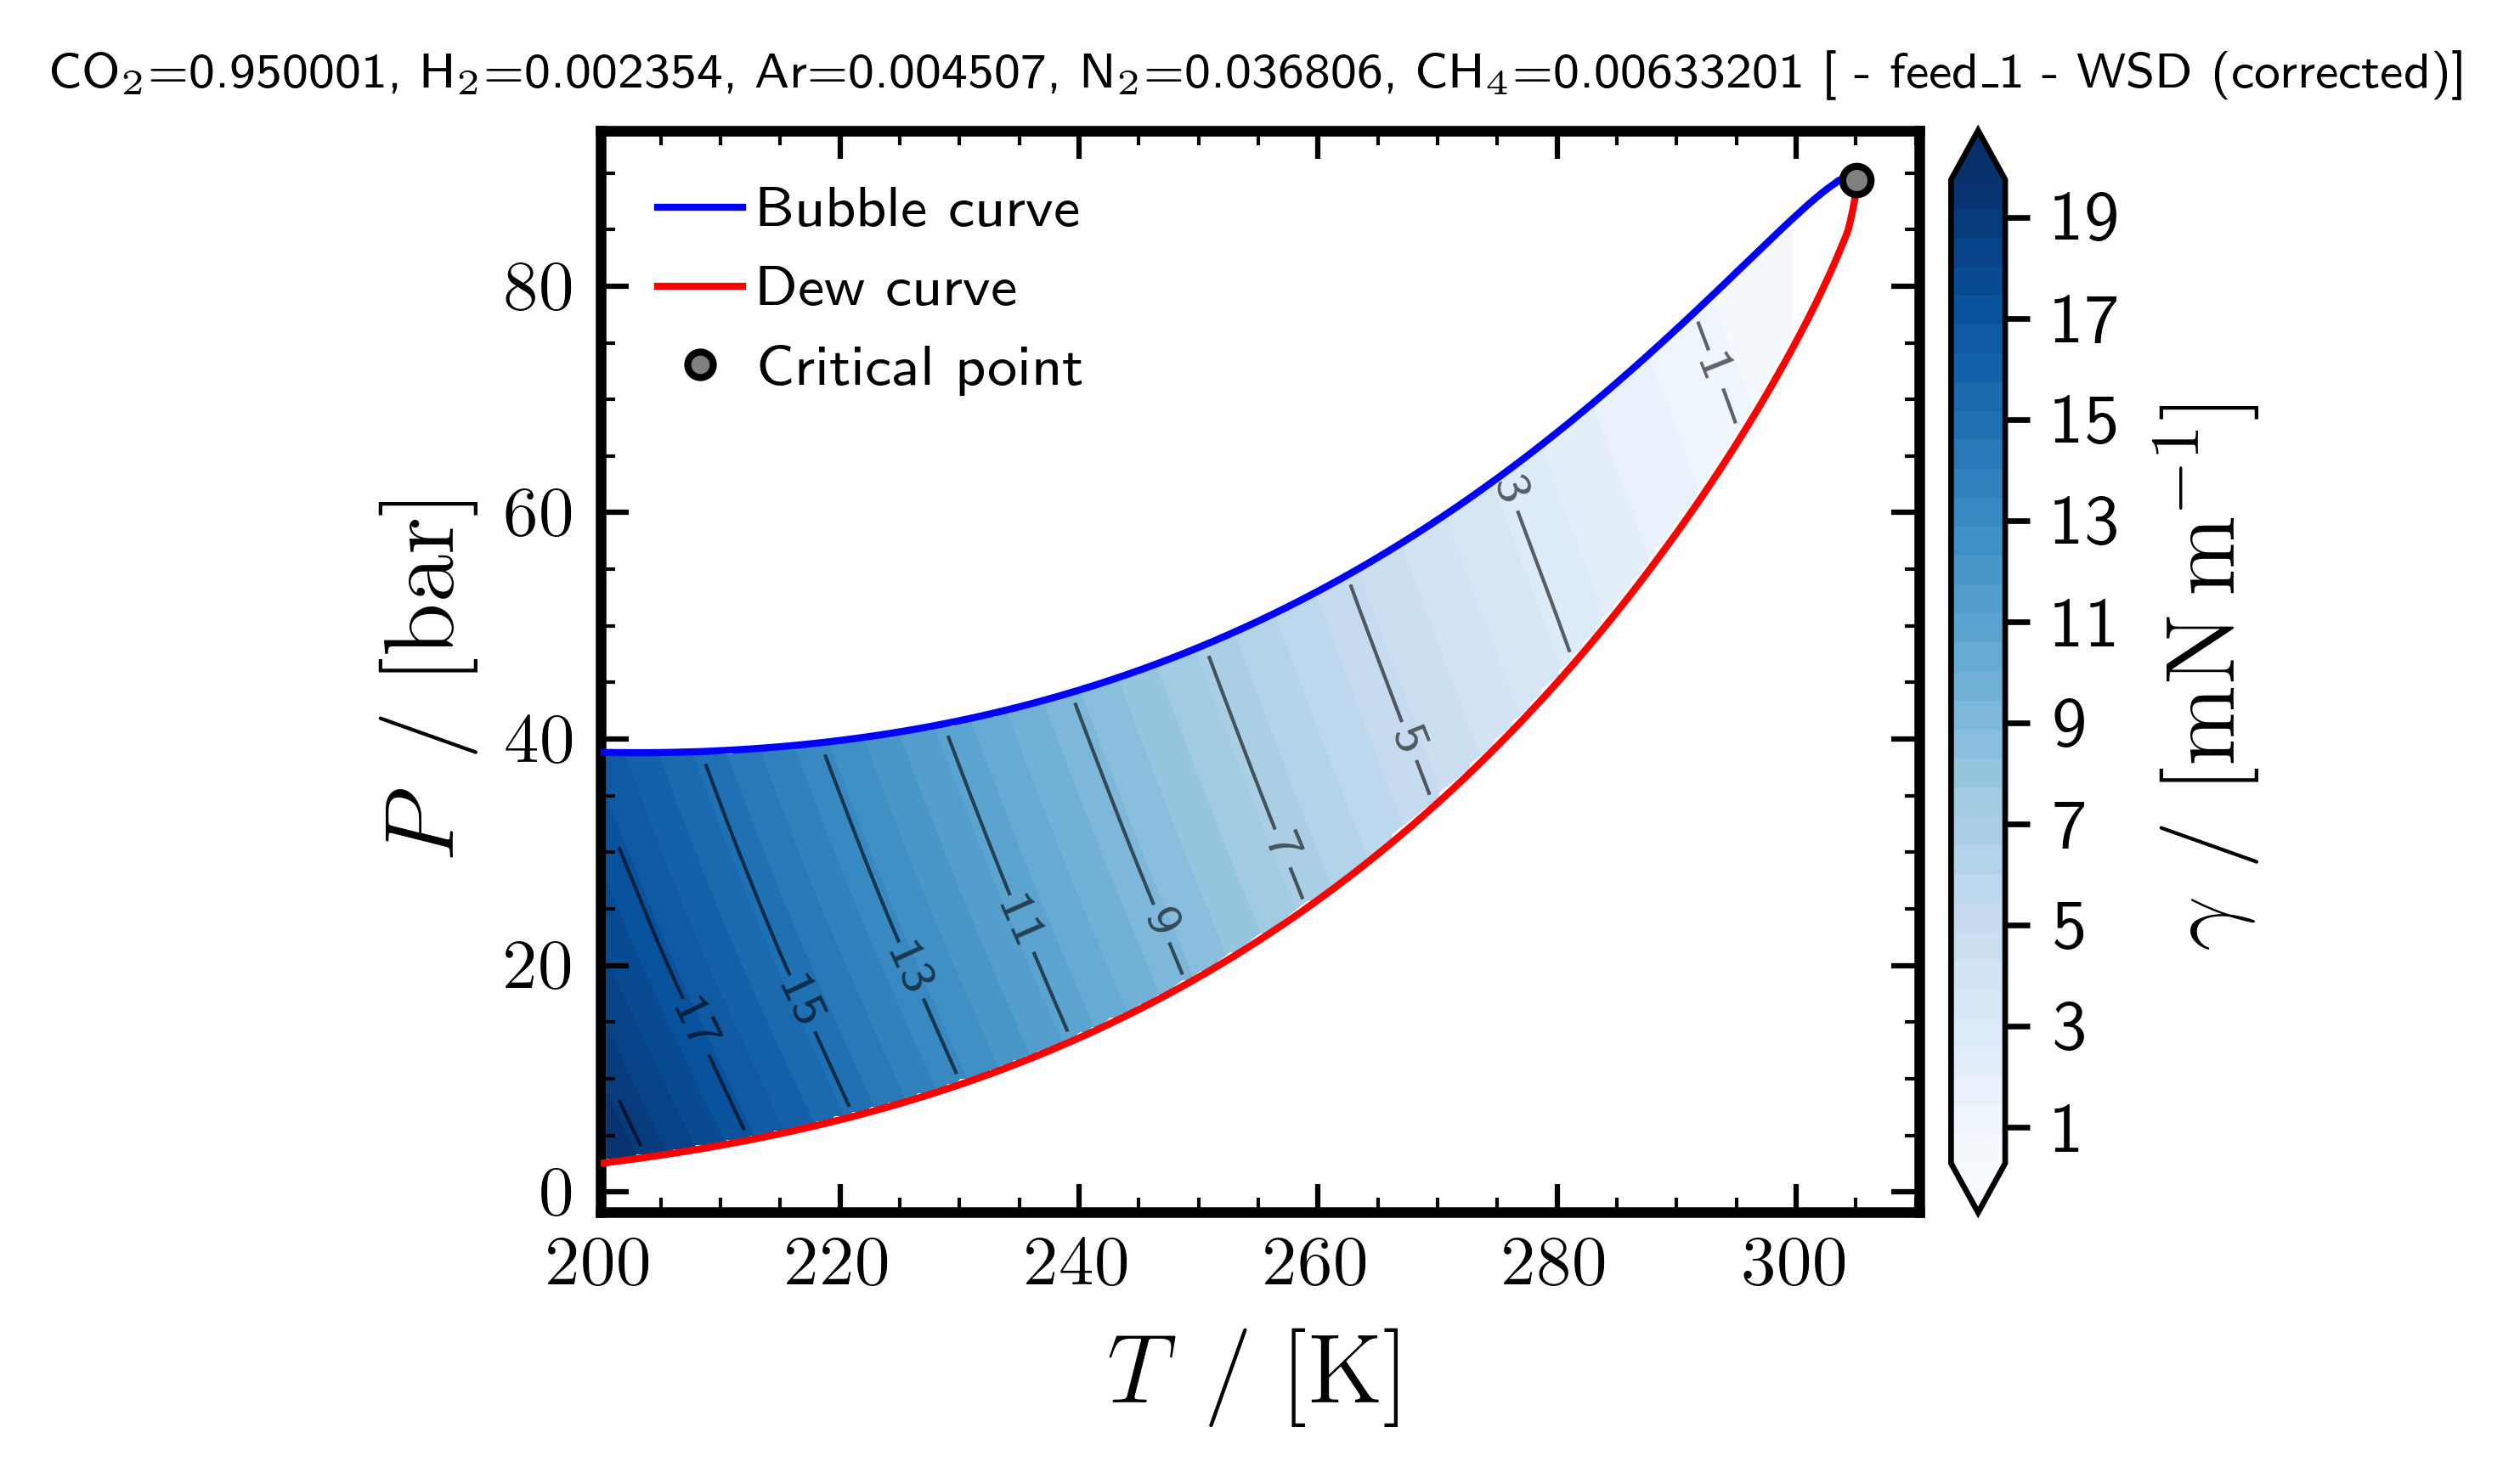

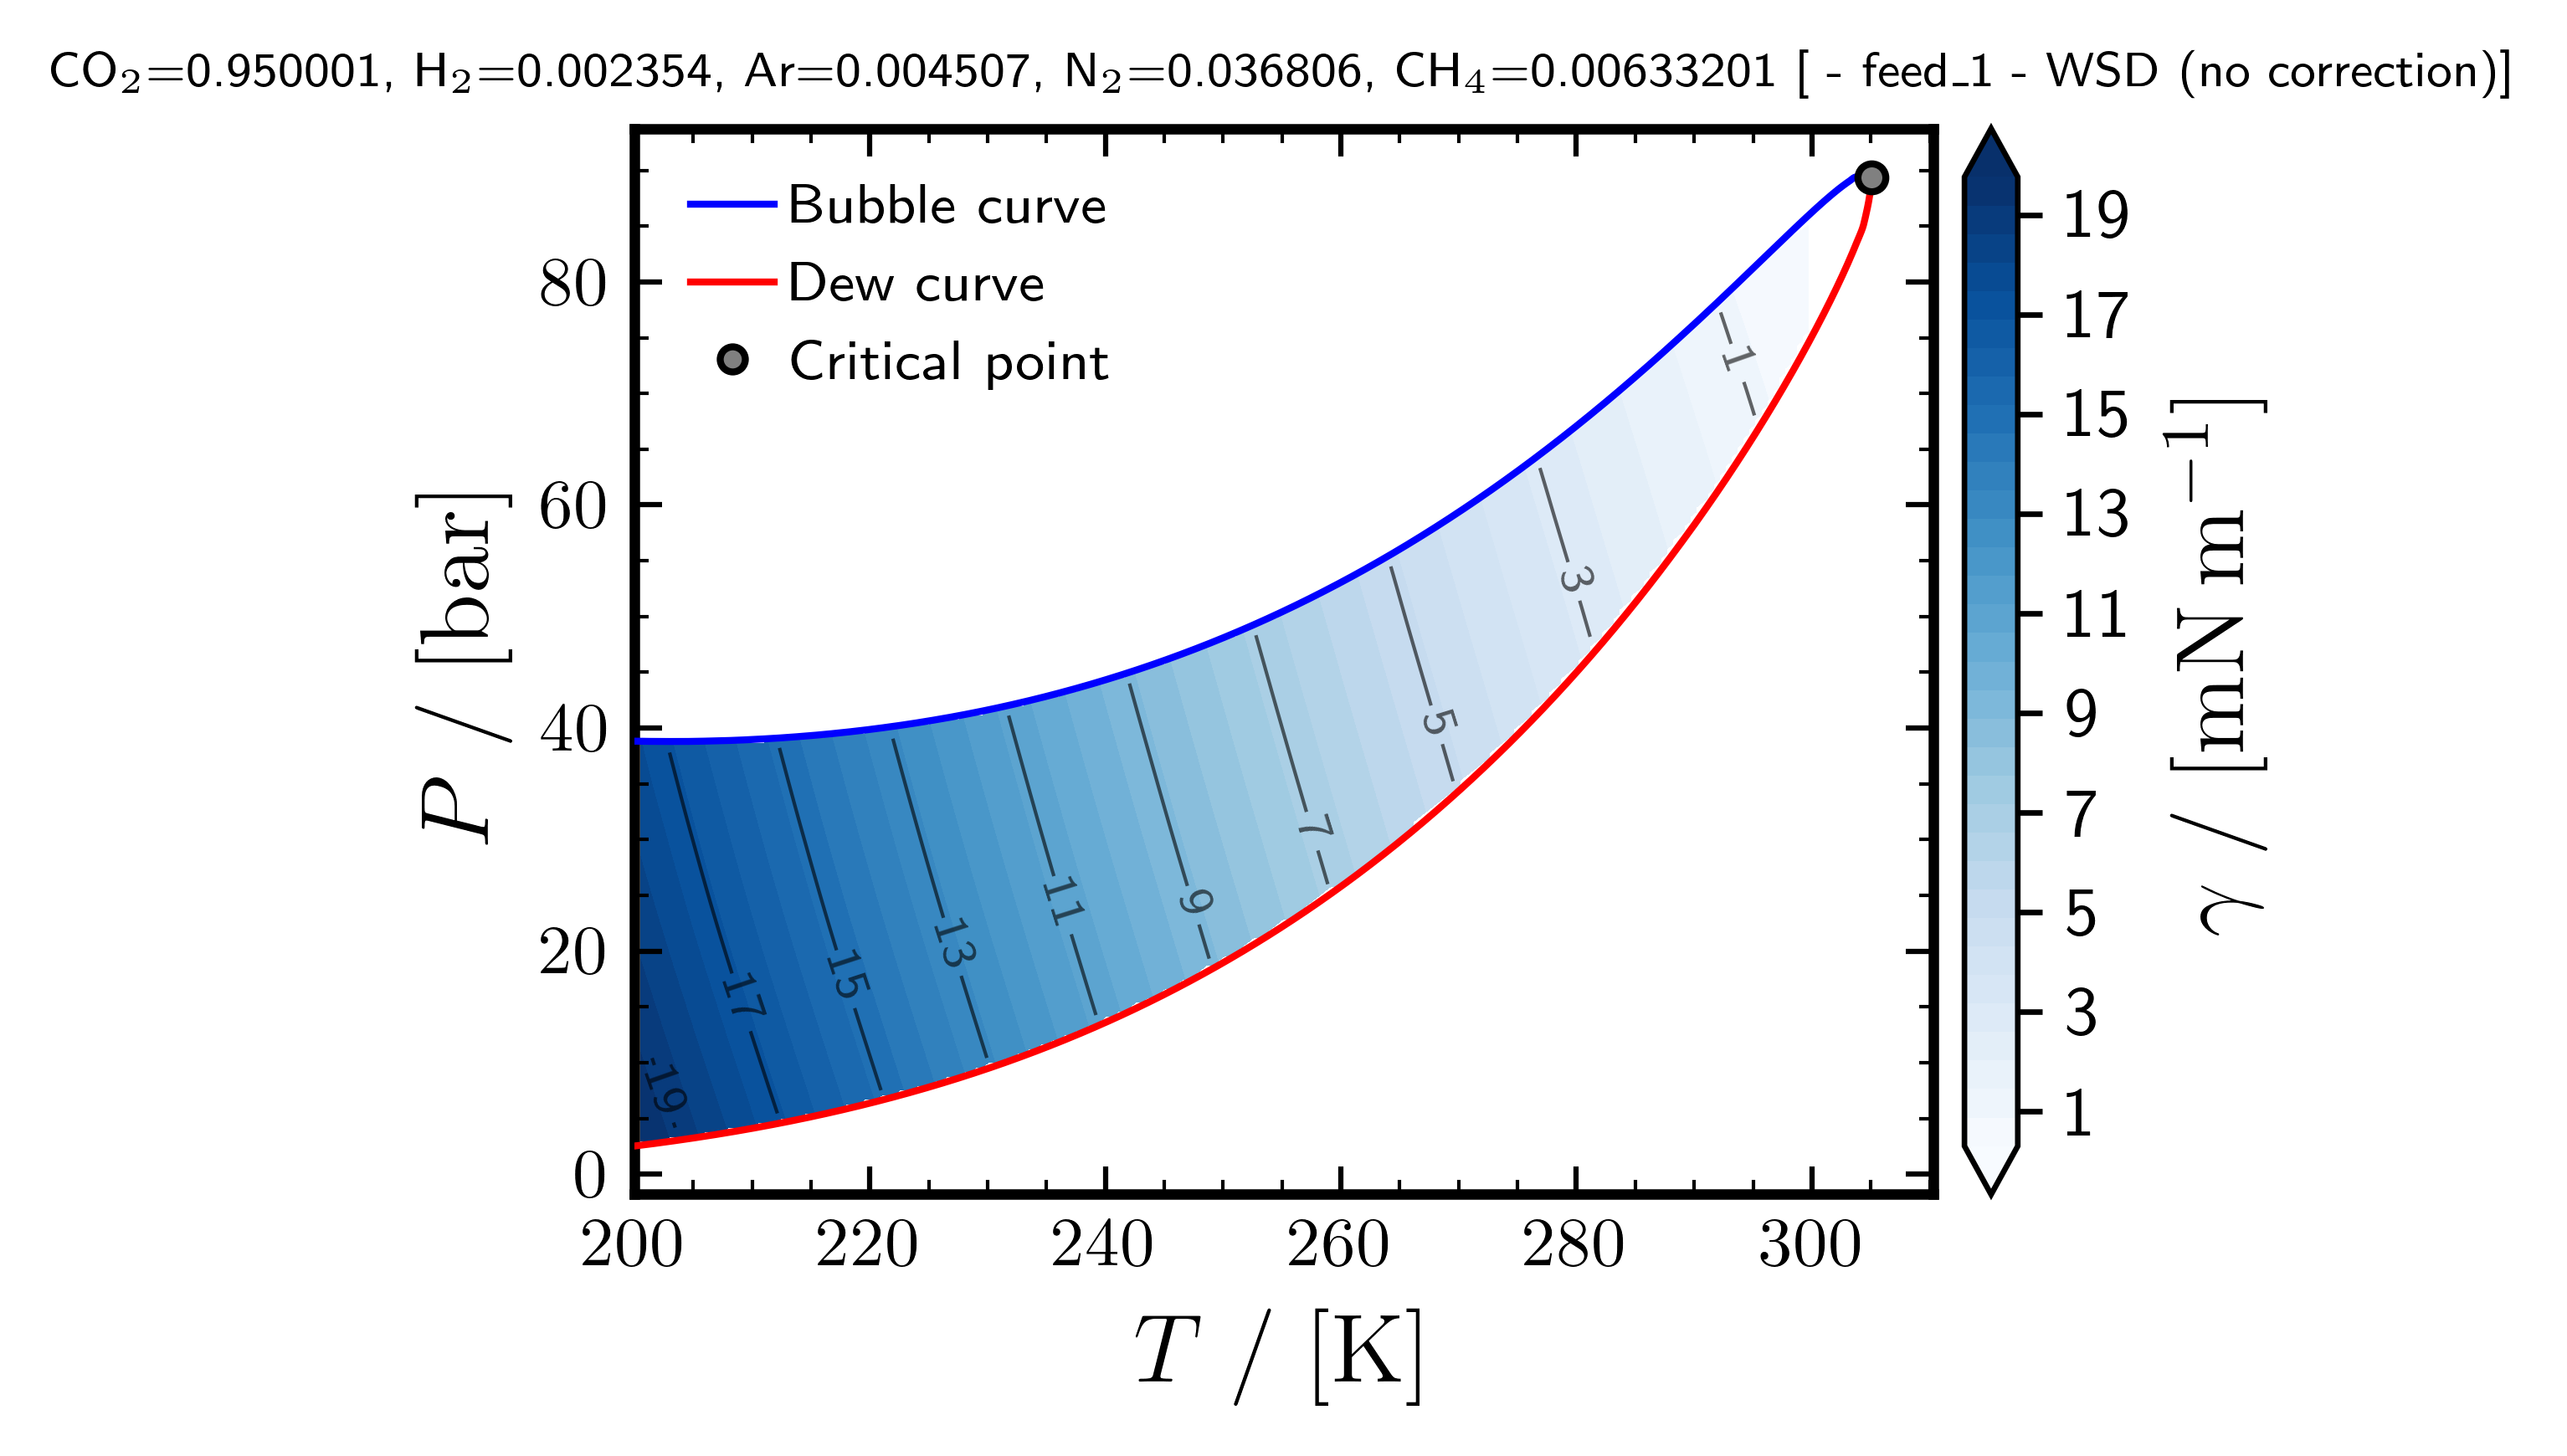

In [8]:
for feed_key, result in sec_results.items():

    FEED_Z = result["z"]
    Tc_K   = result["Tc_K"]
    Pc_bar = result["Pc_bar"]

    T_bub_all = result["T_bub_all"]
    P_bub_all = result["P_bub_all"]
    T_dew_all = result["T_dew_all"]
    P_dew_all = result["P_dew_all"]

    data_parachor  = result["parachor"]
    data_wsd       = result["wsd"]
    data_wsd_nocorr = result["wsd_nocorr"]

    params_ref = PARAMETERS(
        COMPONENTS,
        T_K=T_initial_guess,
        kij_builder=builder,
        model_map=KIJ_map
    )

    # --- Parachor ---
    fig1, ax1 = SEC.semi_emperical_correlations.plot_PT_colormap(
        data=data_parachor,
        T_bub=T_bub_all, P_bub=P_bub_all,
        T_dew=T_dew_all, P_dew=P_dew_all,
        Tc_K=Tc_K, Pc_bar=Pc_bar,
        params=params_ref, feed_z=FEED_Z,
        title_suffix=f" - {feed_key} - Parachor (T-dependent)",
    )
    plt.savefig(f"{OUTPUT_FOLDER}/PNG/colormap_parachor_Tdep_{feed_key}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{OUTPUT_FOLDER}/PDF/colormap_parachor_Tdep_{feed_key}.pdf", bbox_inches="tight")
    plt.show()

    # --- WSD corrected ---
    fig2, ax2 = SEC.semi_emperical_correlations.plot_PT_colormap(
        data=data_wsd,
        T_bub=T_bub_all, P_bub=P_bub_all,
        T_dew=T_dew_all, P_dew=P_dew_all,
        Tc_K=Tc_K, Pc_bar=Pc_bar,
        params=params_ref, feed_z=FEED_Z,
        title_suffix=f" - {feed_key} - WSD (corrected)",
    )
    plt.savefig(f"{OUTPUT_FOLDER}/PNG/colormap_wsd_{feed_key}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{OUTPUT_FOLDER}/PDF/colormap_wsd_{feed_key}.pdf", bbox_inches="tight")
    plt.show()

    # --- WSD no correction ---
    fig3, ax3 = SEC.semi_emperical_correlations.plot_PT_colormap(
        data=data_wsd_nocorr,
        T_bub=T_bub_all, P_bub=P_bub_all,
        T_dew=T_dew_all, P_dew=P_dew_all,
        Tc_K=Tc_K, Pc_bar=Pc_bar,
        params=params_ref, feed_z=FEED_Z,
        title_suffix=f" - {feed_key} - WSD (no correction)",
    )
    plt.savefig(f"{OUTPUT_FOLDER}/PNG/colormap_wsd_nocorr_{feed_key}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{OUTPUT_FOLDER}/PDF/colormap_wsd_nocorr_{feed_key}.pdf", bbox_inches="tight")
    plt.show()

## Cell 9: Writing the SEC data to Dataframes, CSV

In [9]:
# --- Save SEC PT colormap DataFrames for each feed ---
all_dfs_PT = {}

for feed_key, sec_data in sec_results.items():

    # --- Build cDFT data dict for direct merge (no interpolation) ---
    T_cdft, P_cdft, G_cdft = [], [], []

    for T_K, data_list in VLE_DFT[feed_key]["interfacial_data"].items():
        for pt in data_list:
            if "gamma" in pt and not np.isnan(pt["gamma"]):
                T_cdft.append(pt["temperature"])
                P_cdft.append(pt["pressure"])
                G_cdft.append(pt["gamma"])

    data_cdft = {"T": T_cdft, "P": P_cdft, "gamma": G_cdft}

    FEED_Z = sec_data["z"]
    component_names = sec_data["components"]
    data_parachor = sec_data["parachor"]
    data_wsd = sec_data["wsd"]
    data_wsd_nocorr = sec_data["wsd_nocorr"]

    safe_feed_key = str(feed_key).replace(" ", "_").replace("/", "_")

    dfs_PT = SEC.semi_emperical_correlations.save_PT_colormap_dataframes(
        data_parachor=data_parachor,
        data_wsd=data_wsd,
        output_dir=f"{OUTPUT_FOLDER}/InterfacialProperties",
        component_names=component_names,
        feed_z=FEED_Z,
        n_exp=3.87,
        ML_mode=True,
        main_component_index=0,
        all_components=component_names,
        data_cdft=data_cdft,
        data_wsd_nocorr=data_wsd_nocorr,
        filename_parachor=f"{safe_feed_key}_parachor",
        filename_wsd=f"{safe_feed_key}_wsd",
        verbose=verbose,
    )

    all_dfs_PT[feed_key] = dfs_PT

    df_PT_para = dfs_PT["PT_parachor"]
    df_PT_wsd  = dfs_PT["PT_wsd"]

    if verbose:
        print(f"\nFeed: {feed_key}")
        print("Components:", component_names)
        print("Parachor (T-dep) columns:", list(df_PT_para.columns))
        print("WSD columns:", list(df_PT_wsd.columns))


## Cell 10: Difference colormaps using ColormapDifference class
#### Sign convention: Diff = cDFT - SEC
#### Diff > 0  -->  SEC underpredicts relative to cDFT (Red)
#### Diff < 0  -->  SEC overpredicts relative to cDFT  (Blue)

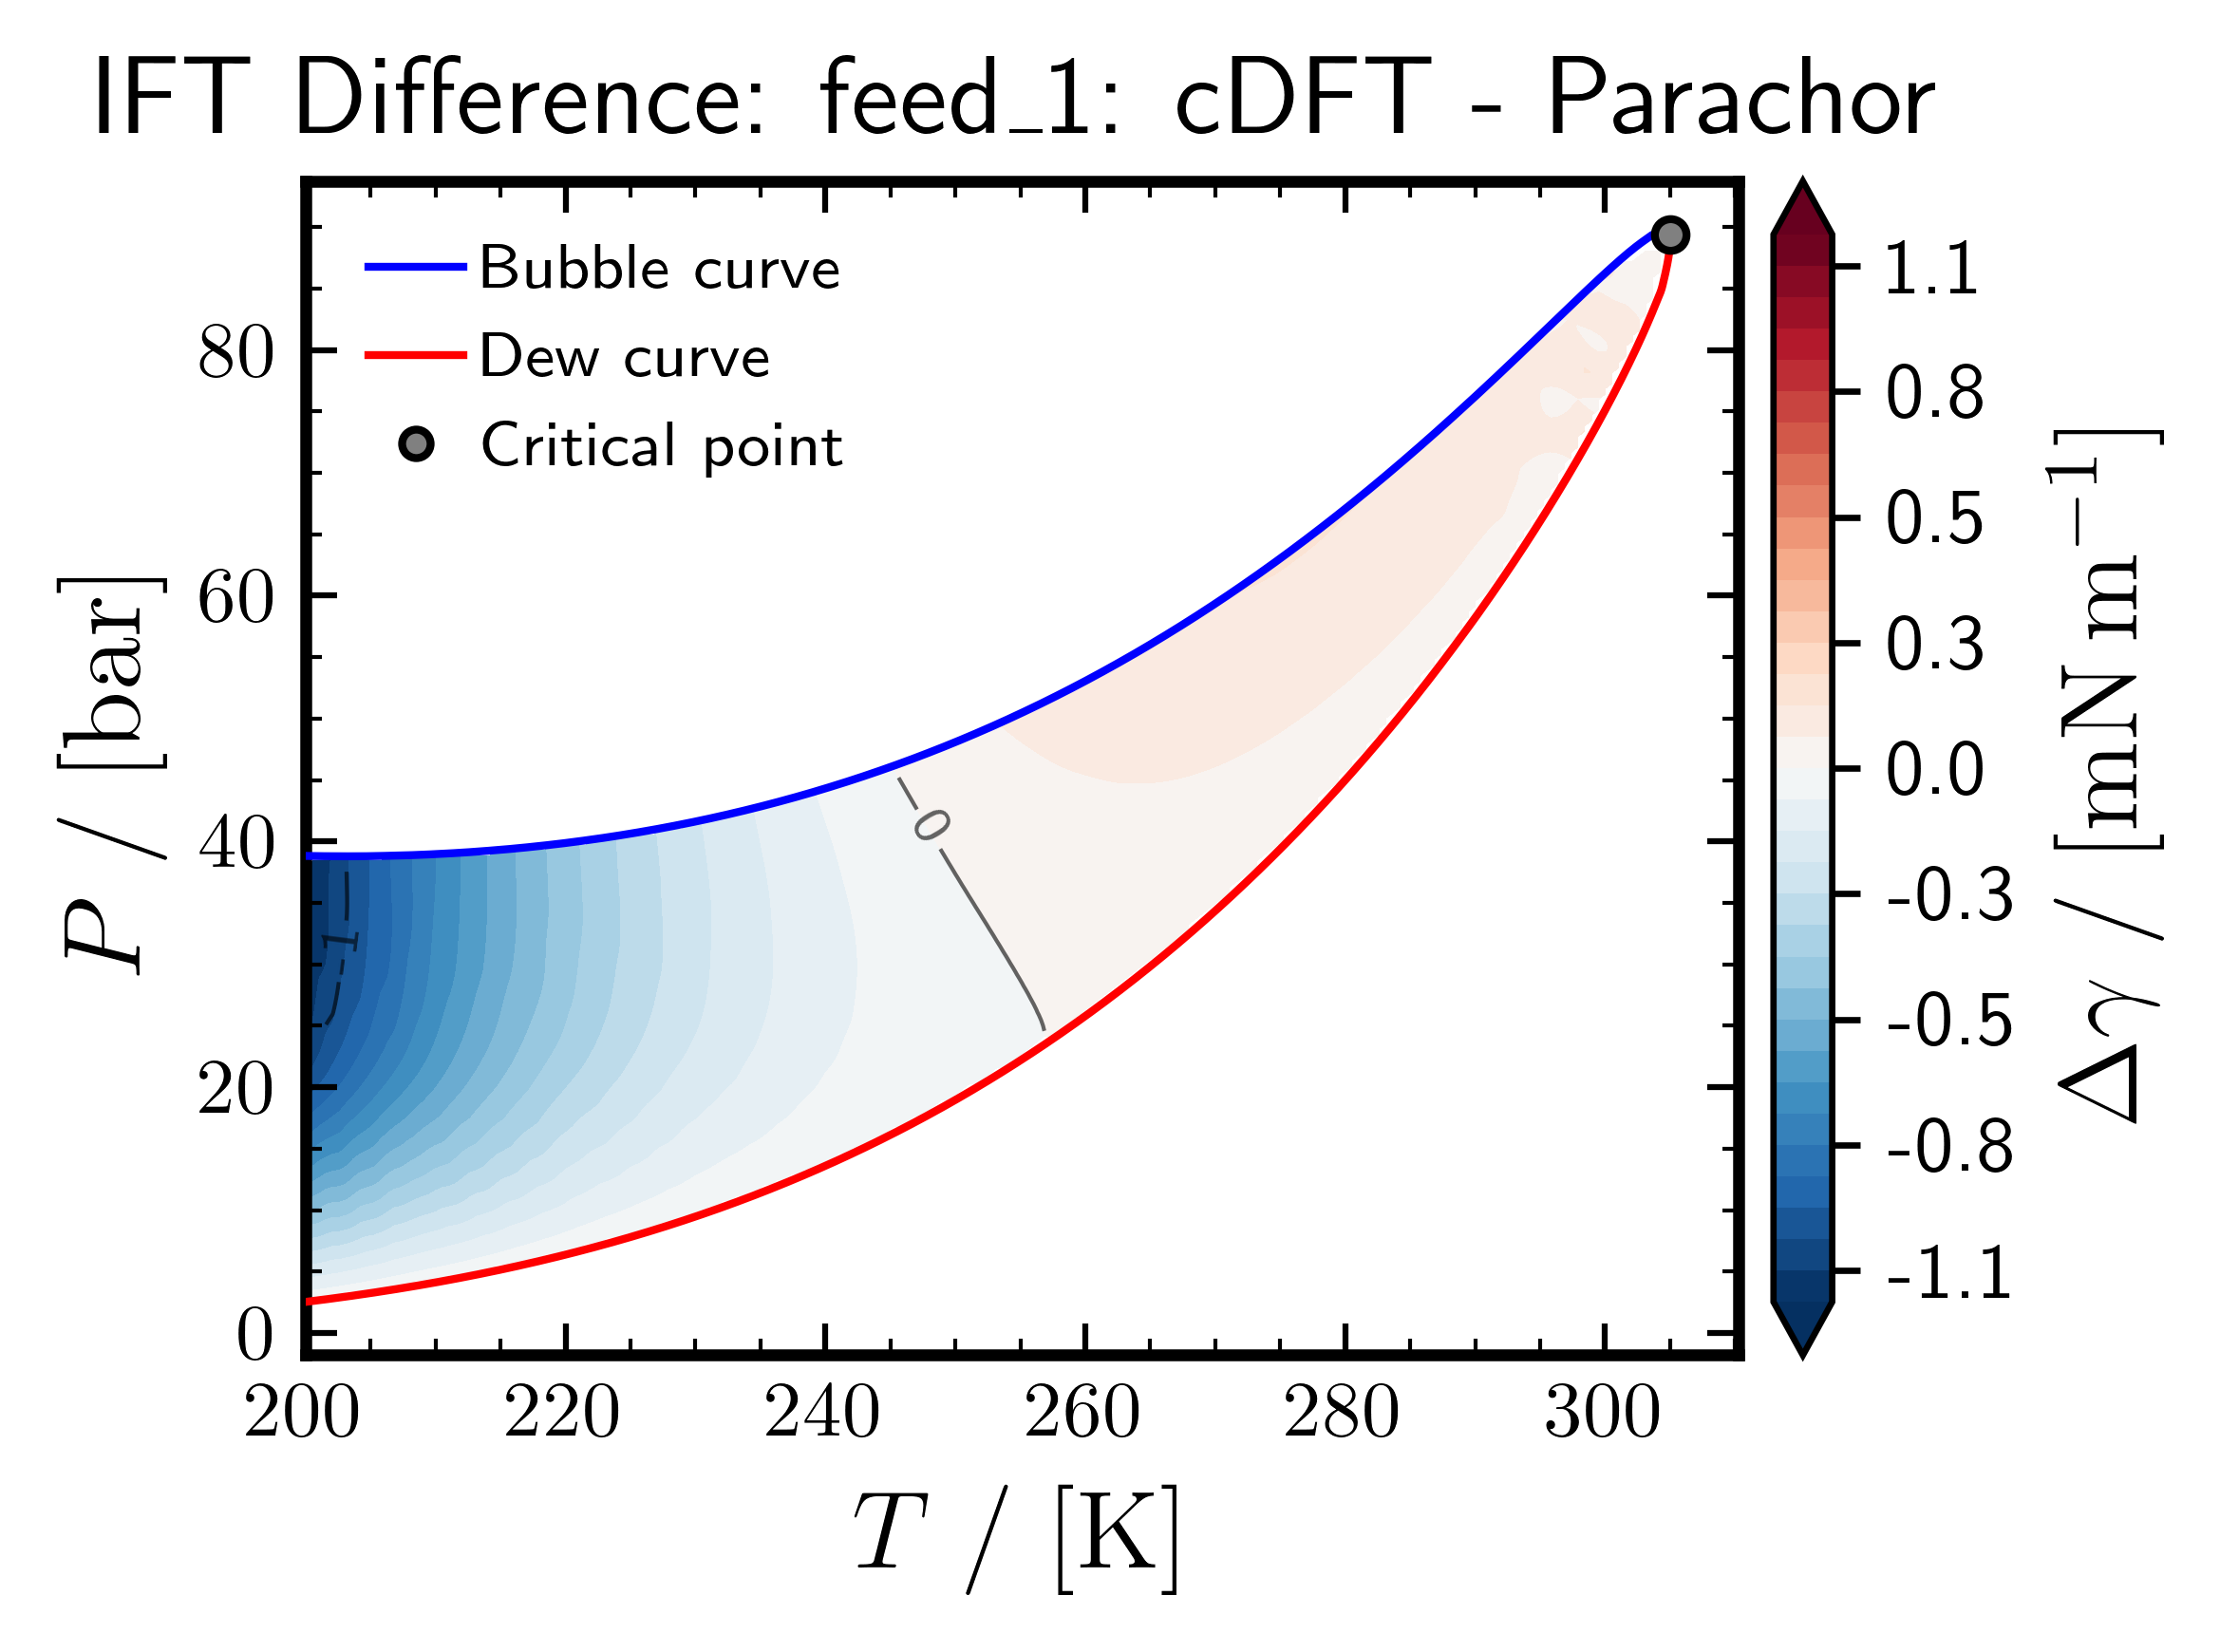

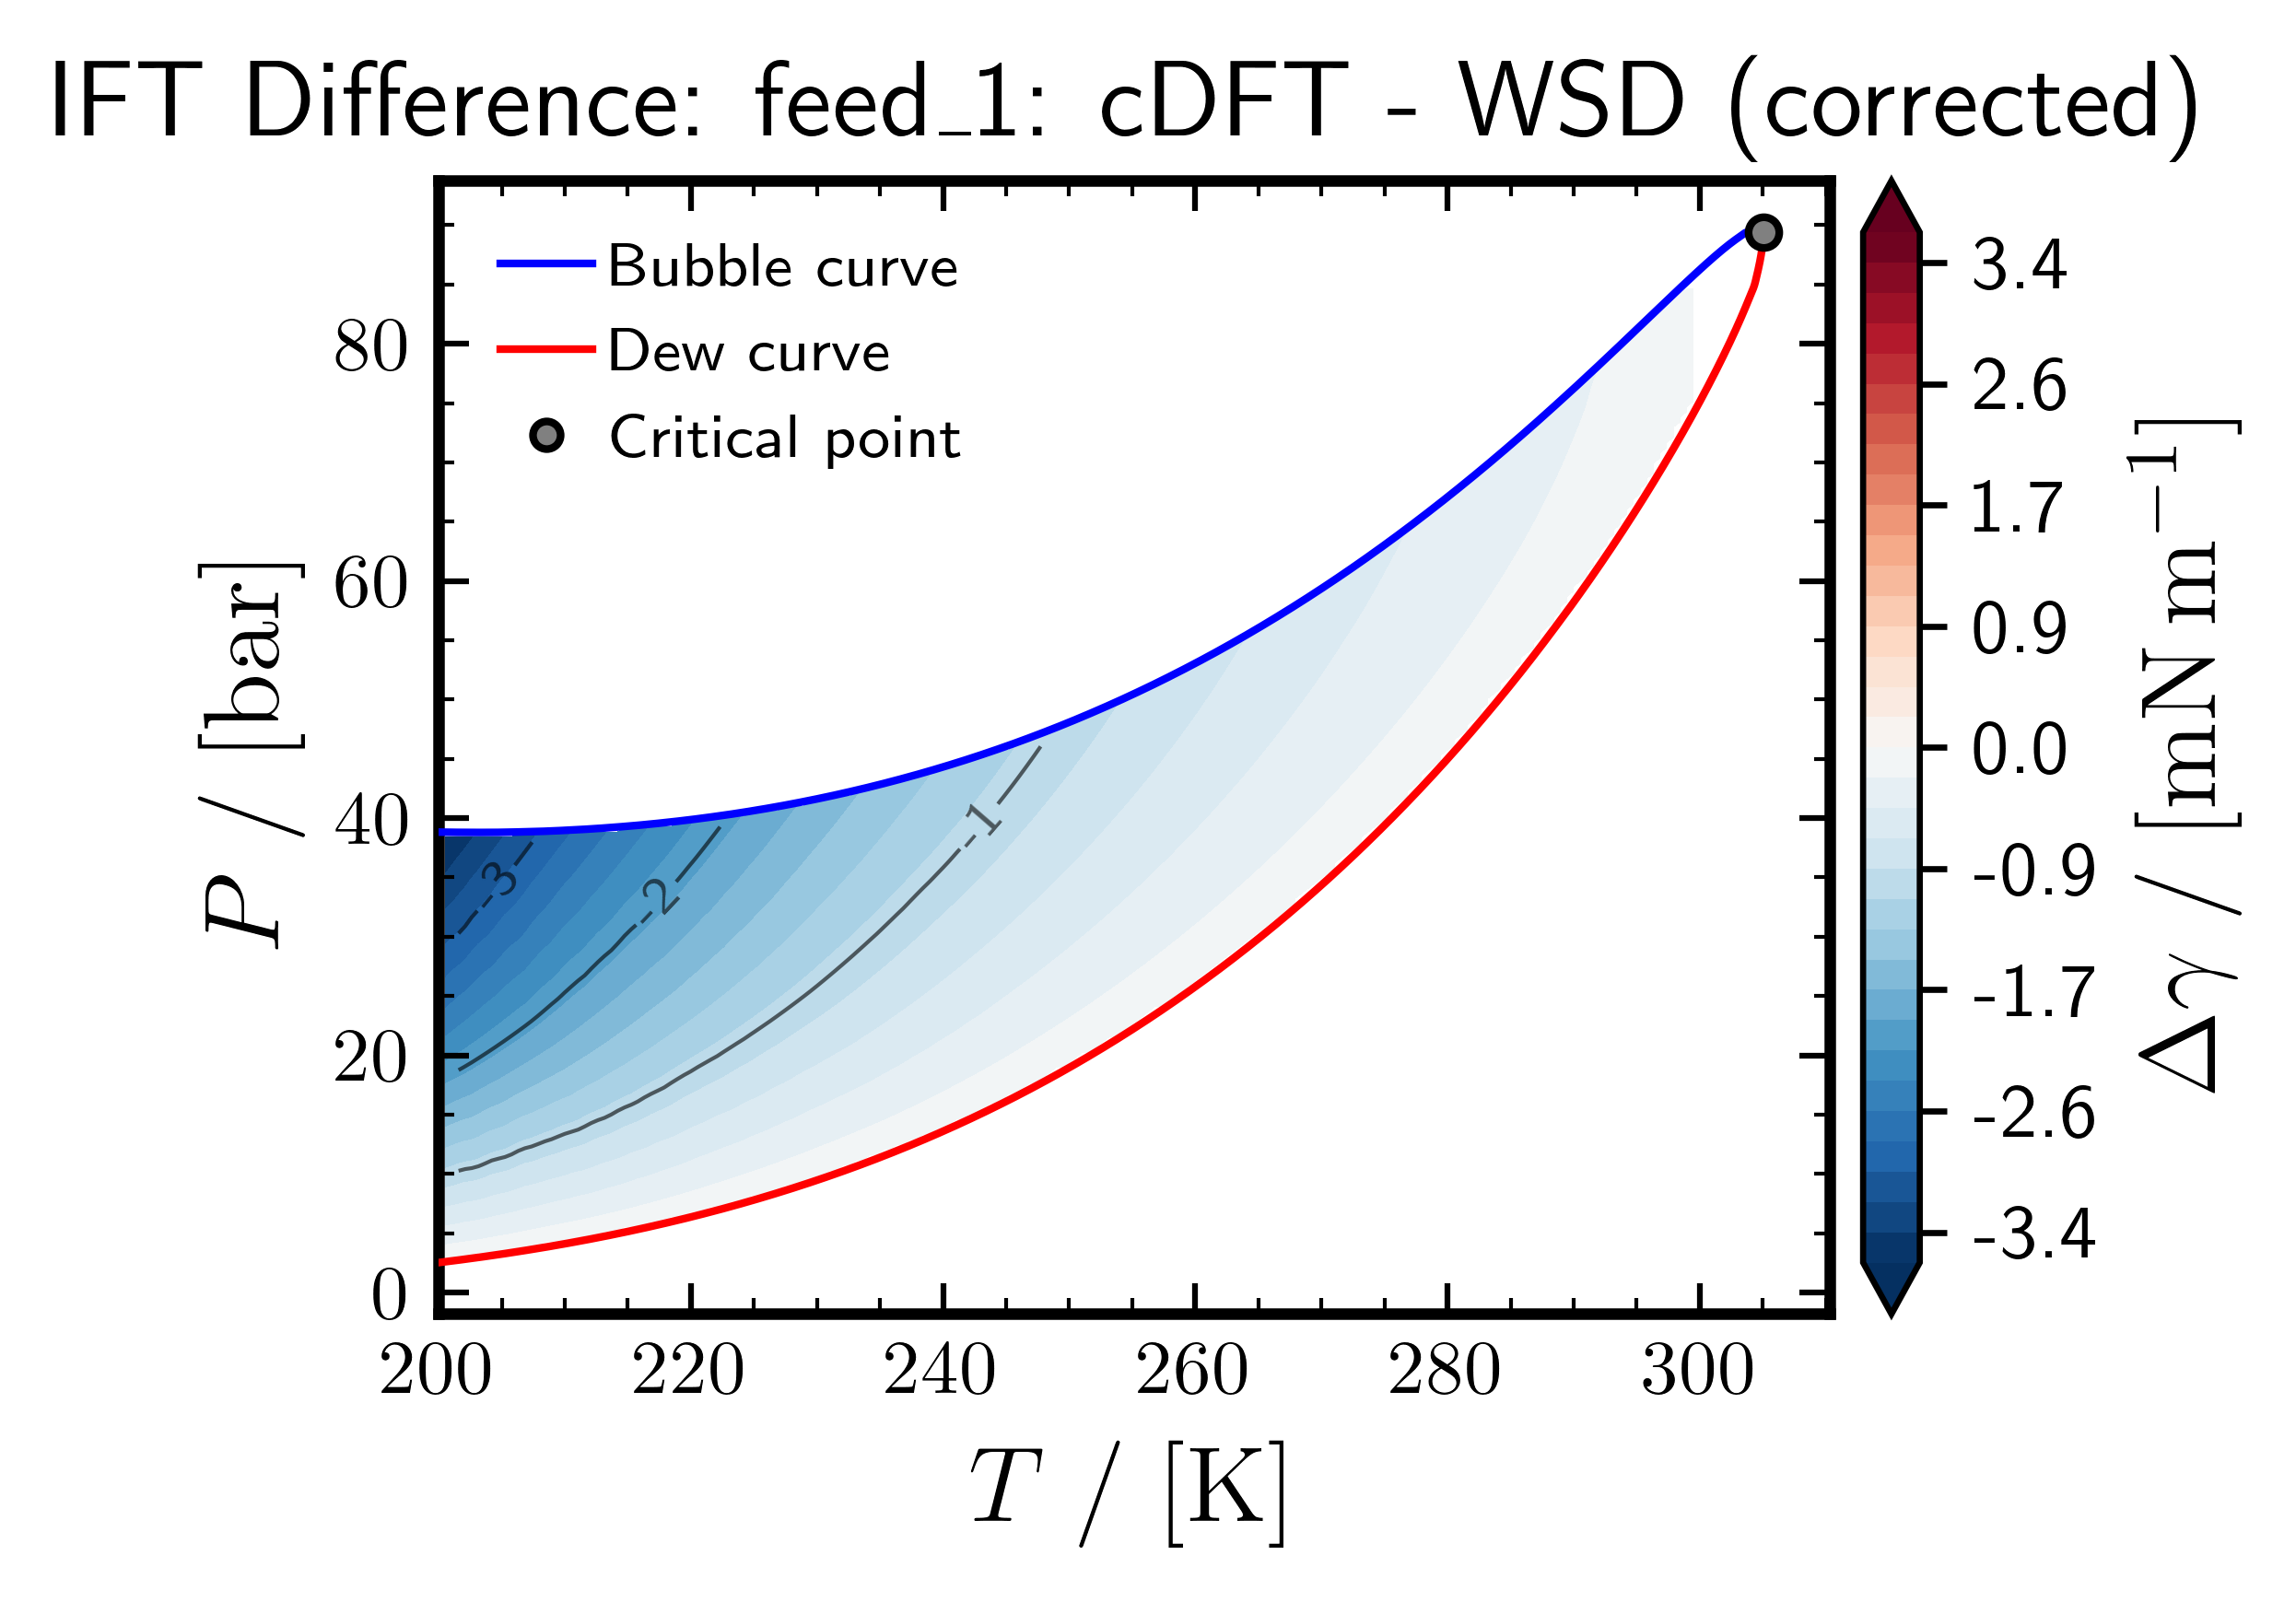

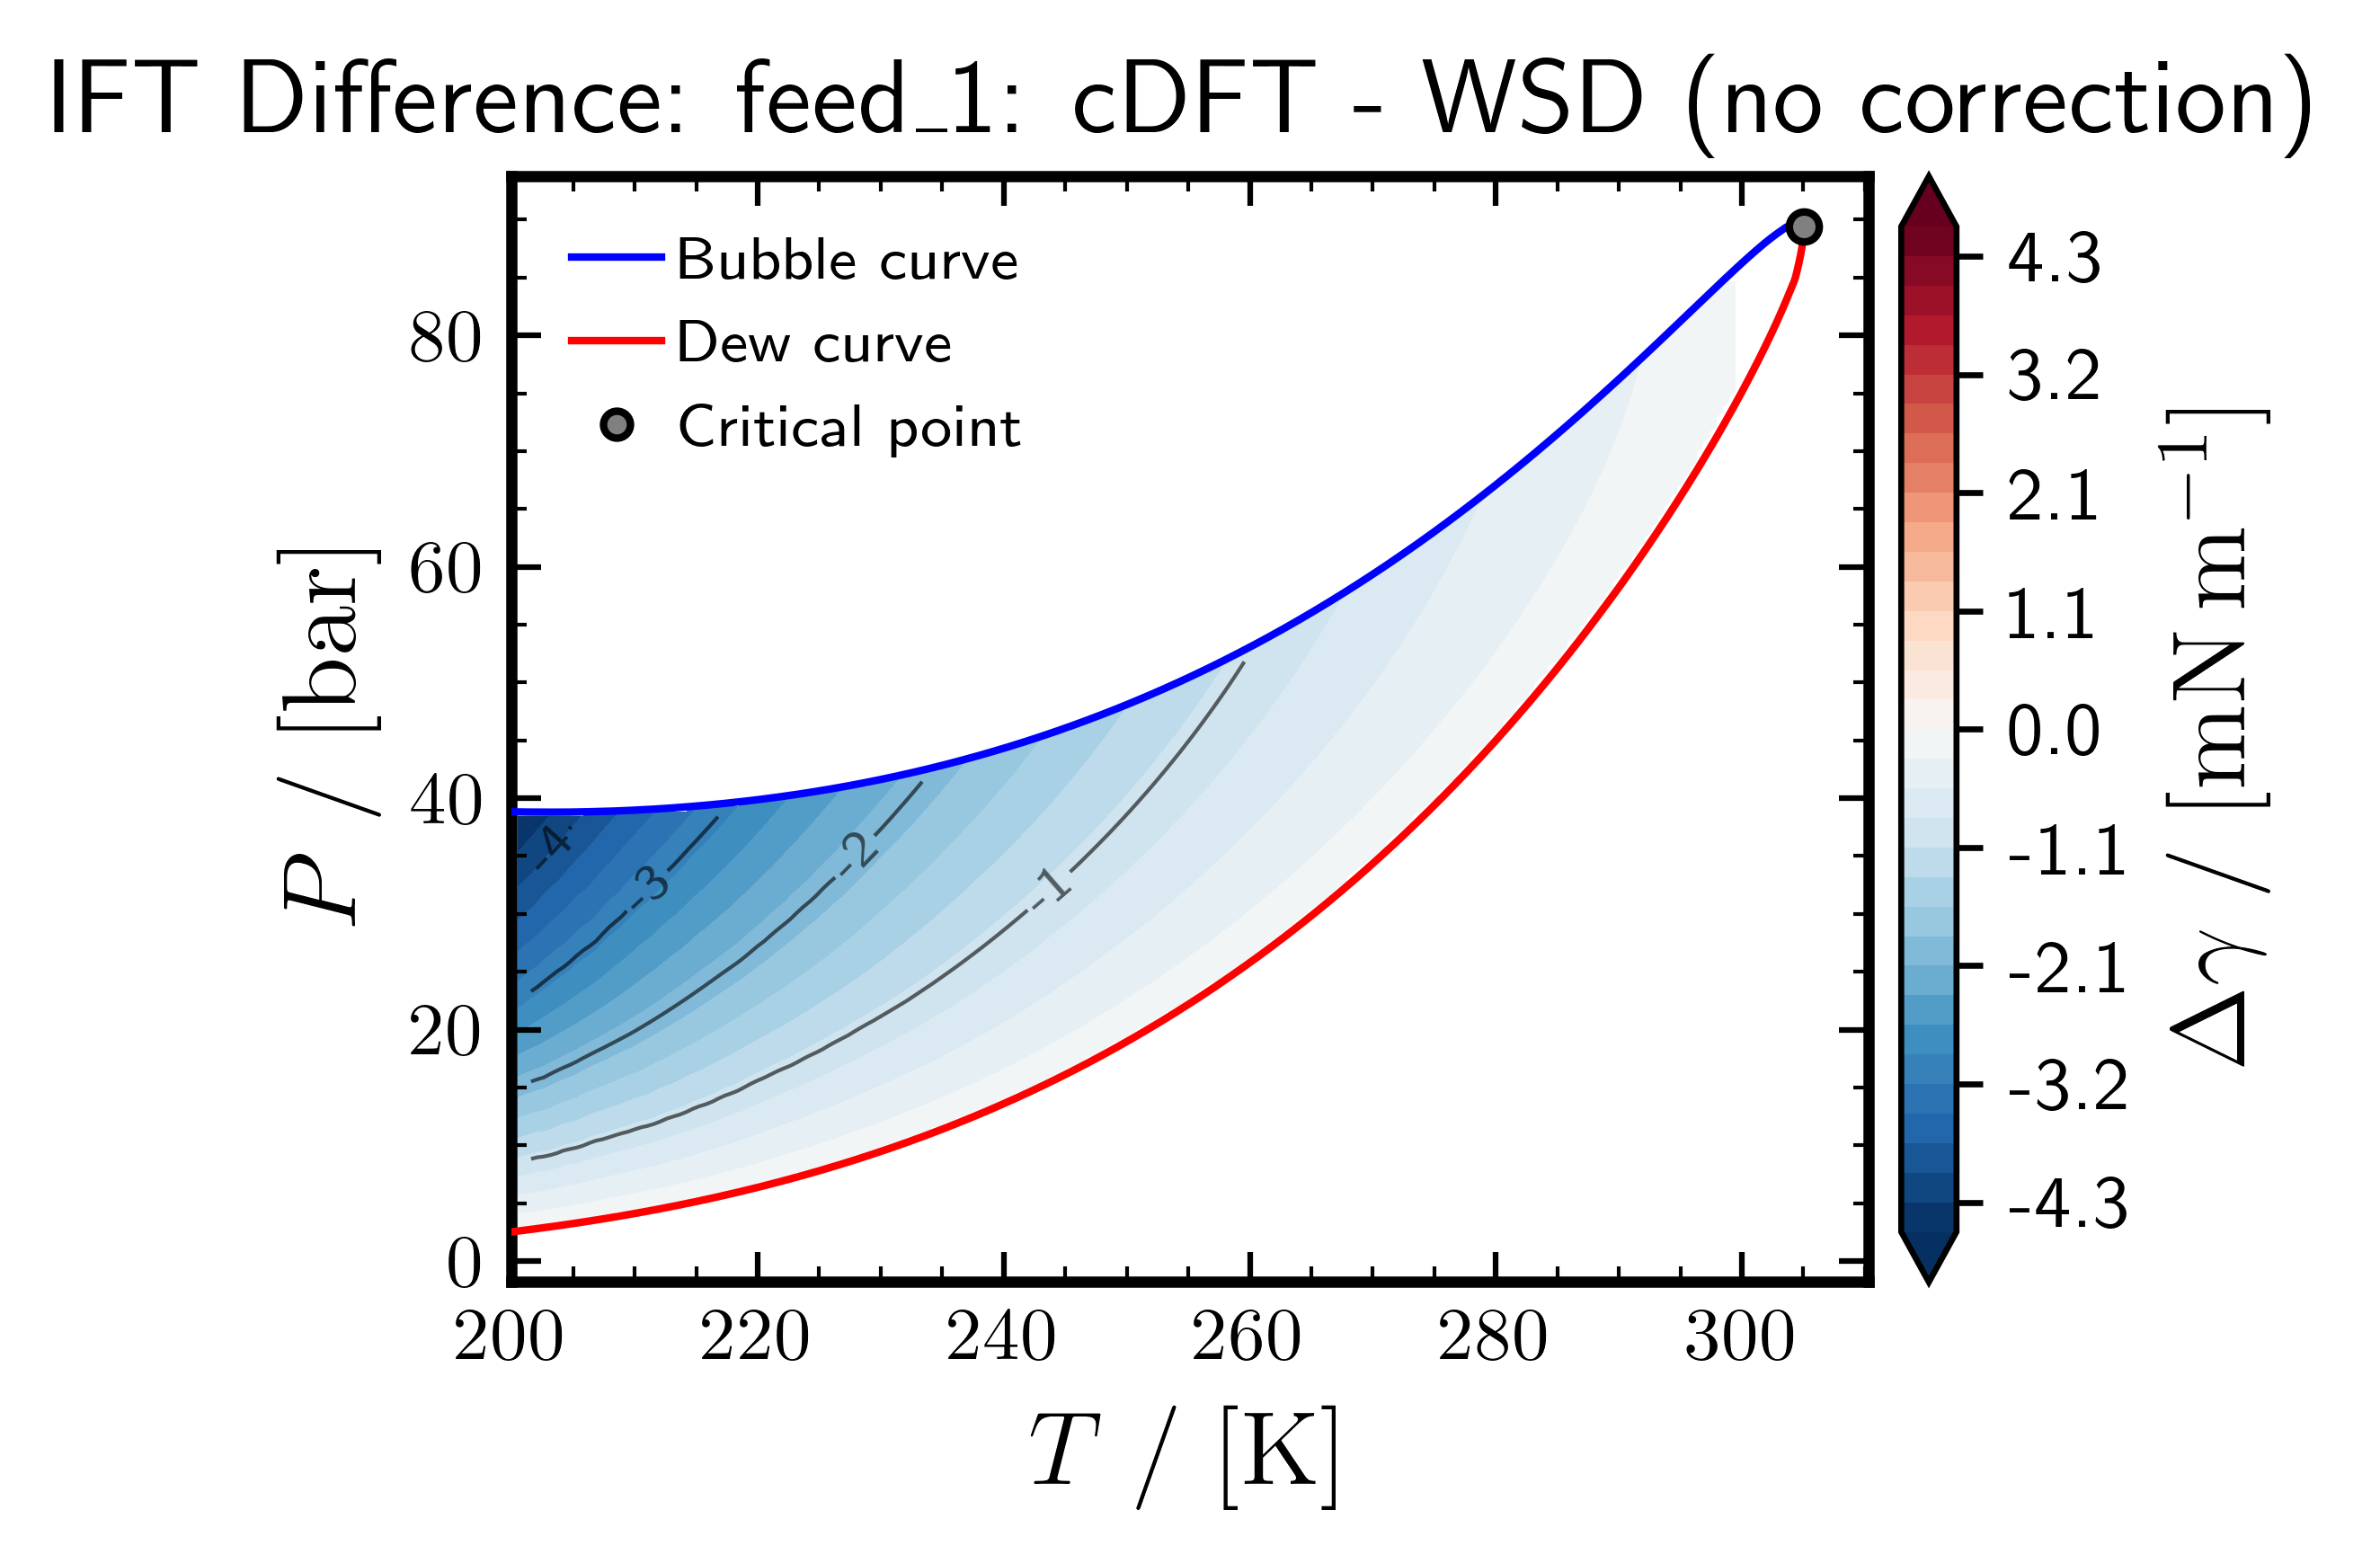

In [10]:
for feed_key, sec_data in sec_results.items():

    if feed_key not in VLE_DFT:
        print(f"Skipping {feed_key} — not found in VLE_DFT")
        continue

    safe_feed_key = str(feed_key).replace(" ", "_").replace("/", "_")

    # Feed-specific PT envelope info
    Tc_K   = sec_data["Tc_K"]
    Pc_bar = sec_data["Pc_bar"]

    T_bub_all = sec_data["T_bub_all"]
    P_bub_all = sec_data["P_bub_all"]
    T_dew_all = sec_data["T_dew_all"]
    P_dew_all = sec_data["P_dew_all"]

    data_parachor   = sec_data["parachor"]
    data_wsd        = sec_data["wsd"]
    data_wsd_nocorr = sec_data["wsd_nocorr"]

    # Build cDFT data dict for this feed
    T_cdft, P_cdft, G_cdft = [], [], []
    for T_K, data_list in VLE_DFT[feed_key]["interfacial_data"].items():
        for pt in data_list:
            if "gamma" in pt and not np.isnan(pt["gamma"]):
                T_cdft.append(pt["temperature"])
                P_cdft.append(pt["pressure"])
                G_cdft.append(pt["gamma"])

    if len(G_cdft) == 0:
        print(f"Skipping {feed_key} — no valid cDFT gamma data")
        continue

    data_cdft = {"T": T_cdft, "P": P_cdft, "gamma": G_cdft}

    diff_pairs = [
        ("cDFT - Parachor",            data_cdft, data_parachor),
        ("cDFT - WSD (corrected)",     data_cdft, data_wsd),
        ("cDFT - WSD (no correction)", data_cdft, data_wsd_nocorr),
    ]

    feed_summaries = []

    for label, dA, dB in diff_pairs:
        cdiff = ColormapDifference(
            data_A=dA, data_B=dB,
            T_bub=T_bub_all, P_bub=P_bub_all,
            T_dew=T_dew_all, P_dew=P_dew_all,
        )

        fig, ax = cdiff.plot(
            Tc_K=Tc_K, Pc_bar=Pc_bar,
            T_bub=T_bub_all, P_bub=P_bub_all,
            T_dew=T_dew_all, P_dew=P_dew_all,
            label=f"{feed_key}: {label}",
            isoline_step=1,
        )

        if fig is not None:
            safe_label = (
                label.replace(" ", "_")
                     .replace("$", "")
                     .replace("-", "minus")
                     .replace("\\", "")
                     .replace("(", "")
                     .replace(")", "")
            )
            plt.savefig(f"{OUTPUT_FOLDER}/PNG/diff_{safe_feed_key}_{safe_label}.png", dpi=300, bbox_inches="tight")
            plt.savefig(f"{OUTPUT_FOLDER}/PDF/diff_{safe_feed_key}_{safe_label}.pdf", bbox_inches="tight")
            plt.show()
        else:
            print(f"Skipping '{feed_key} - {label}' — insufficient overlap data.")

        summary = cdiff.deviation_summary(label=label)
        if summary:
            feed_summaries.append(summary)
            if verbose:
                print(f"\n[{feed_key} | {label}]")
                print(f"  max deviation : {summary['max_deviation_mNm']:+.4f} mN/m  "
                      f"at T={summary['max_deviation_T_K']:.1f} K, P={summary['max_deviation_P_bar']:.2f} bar")
                print(f"  min deviation : {summary['min_deviation_mNm']:+.4f} mN/m  "
                      f"at T={summary['min_deviation_T_K']:.1f} K, P={summary['min_deviation_P_bar']:.2f} bar")
                print(f"  mean deviation: {summary['mean_deviation_mNm']:+.4f} mN/m  |  "
                      f"RMSE: {summary['rmse_mNm']:.4f} mN/m")

    if feed_summaries:
        os.makedirs(OUTPUT_FOLDER, exist_ok=True)
        json_path = os.path.join(OUTPUT_FOLDER, f"Deviations_{safe_feed_key}.json")
        with open(json_path, "w") as f:
            json.dump(feed_summaries, f, indent=4)


In [11]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 1.67 minutes
